In [2]:
%pip install "numpy<2"

     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
      --------------------------------------- 0.2/15.8 MB 4.1 MB/s eta 0:00:04
     - -------------------------------------- 0.4/15.8 MB 5.4 MB/s eta 0:00:03
     --- ------------------------------------ 1.4/15.8 MB 10.7 MB/s eta 0:00:02
     ----- ---------------------------------- 2.2/15.8 MB 12.8 MB/s eta 0:00:02
     --------- ------------------------------ 3.6/15.8 MB 16.2 MB/s eta 0:00:01
     ------------ --------------------------- 4.9/15.8 MB 18.6 MB/s eta 0:00:01
     -------------- ------------------------- 5.8/15.8 MB 18.5 MB/s eta 0:00:01
     --------------- ------------------------ 6.0/15.8 MB 18.2 MB/s eta 0:00:01
     --------------- ------------------------ 6.0/15.8 MB 18.2 MB/s eta 0:00:01
     --------------- ------------------------ 6.0/15.8 MB 18.2 MB/s eta 0:00:01
     ------------------- -------------------- 7.6/15.8 MB 15.1 MB/s eta 0:00:01
     --------------------- ------------------ 8.7/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\arran\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

import sys
print("ACTUAL PYTHON VERSION RUNNING:", sys.version)

Num GPUs Available:  2
ACTUAL PYTHON VERSION RUNNING: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


## Download version of data set

In [ ]:
path = kh.dataset_download("alessiocorrado99/animals10") # downloads the Animals-10 dataset from kaggle 
datapath = os.path.join(path,"raw-img") # builds correct path to images 
print ("using dataset path:",datapath) # prints dataset lecation 
print ("Contents:", os.listdir(datapath)) # lists all class folders 

# Version 1
### 28,28 image resolution
### 32 batch size 
### 16 and 16 filter layer model

The result of 54% accuracy on the test set, 54% on the validation, which is better than random guessing, however it is barely guessing more than half successfully indicating that it is struggling.
Training accuracy only reaches about 6%, and the training loss levels out at about 1.13. Due to this low training performance the model is underfitting as it doesn't have sufficient capacity or enough information to learn teh training data properly. 
Therefore it stopped at epoch 12 as the validation stopped improving around epoch 9.

The model performs the worst at guessing cats and could accurately guess roughly 10% of them and many were misclassified as dogs, this is likely due to the very low resolution images and that they share very similar characteristics. Dogs are also slightly over represented in the data set so if the model needs to guess then it is more likely to guess dog. 

The model managed to successfully guess many spiders successfully, however this was likely only due to the fact that it predicted spider for many of the images. It likely did this as the spider's distinctive features survived the downscaling relatively well and the model overly relied on those patterns. 

The main problem with this model is that it is too simple as the network only has 2 convolution layers with 16 filters, which is not deep enough to effectively capture complex features. The downscaling process also removes most of the animals key features. To improve the model, the next iteration will increase the image dimensions to 64,64 and increase the filters in the 2 convolution layers to 32 and 64

Num GPUs Available:  2
using dataset path: C:\Mechanical engineering\Big Data\BigData\raw-img
Contents: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.
Checking Train Set (18322 total images across 573 batches)...
=== Train Set Check Complete ===
Valid images: 18322 | Invalid images: 0

Checking Validation Set (3922 total images across 123 batches)...
=== Validation Set Check Complete ===
Valid images: 3922 | Invalid images: 0

Checking Test Set (3935 total images across 123 batches)...
=== Test Set Check Complete ===
Valid images: 3935 | Invalid images: 0

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


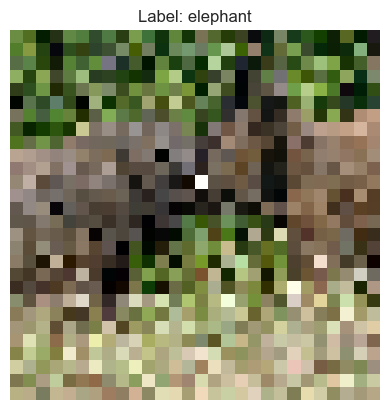

* Train - dog: 3404
* Train - horse: 1836
* Train - elephant: 1012
* Train - butterfly: 1478
* Train - chicken: 2168
* Train - cat: 1167
* Train - cow: 1306
* Train - sheep: 1274
* Train - spider: 3374
* Train - squirrel: 1303
* Validation - dog: 729
* Validation - horse: 393
* Validation - elephant: 216
* Validation - butterfly: 316
* Validation - chicken: 464
* Validation - cat: 250
* Validation - cow: 279
* Validation - sheep: 273
* Validation - spider: 723
* Validation - squirrel: 279
* Test - dog: 730
* Test - horse: 394
* Test - elephant: 218
* Test - butterfly: 318
* Test - chicken: 466
* Test - cat: 251
* Test - cow: 281
* Test - sheep: 273
* Test - spider: 724
* Test - squirrel: 280


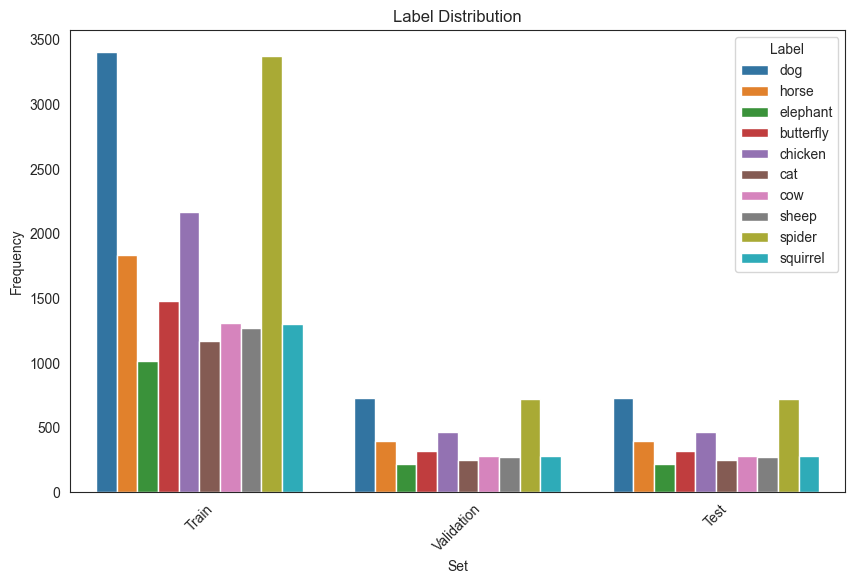

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_50 (Conv2D)          (None, 26, 26, 16)        448       
                                                                 
 max_pooling2d_50 (MaxPoolin  (None, 13, 13, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_51 (Conv2D)          (None, 11, 11, 16)        2320      
                                                                 
 max_pooling2d_51 (MaxPoolin  (None, 5, 5, 16)         0         
 g2D)                                                            
                                                                 
 flatten_19 (Flatten)        (None, 400)               0         
                                                                 
 dense_38 (Dense)            (None, 128)             

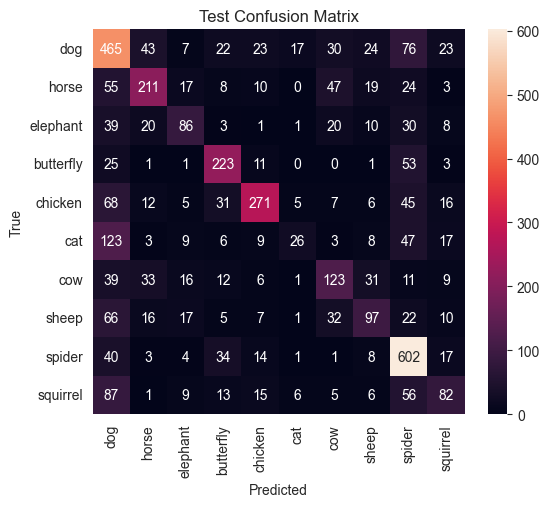

Test Set Report
              precision    recall  f1-score   support

         dog       0.46      0.64      0.54       730
       horse       0.62      0.54      0.57       394
    elephant       0.50      0.39      0.44       218
   butterfly       0.62      0.70      0.66       318
     chicken       0.74      0.58      0.65       466
         cat       0.45      0.10      0.17       251
         cow       0.46      0.44      0.45       281
       sheep       0.46      0.36      0.40       273
      spider       0.62      0.83      0.71       724
    squirrel       0.44      0.29      0.35       280

    accuracy                           0.56      3935
   macro avg       0.54      0.49      0.49      3935
weighted avg       0.55      0.56      0.54      3935


Validation Set Evaluation
123/123 [==============================] - 3s 28ms/step


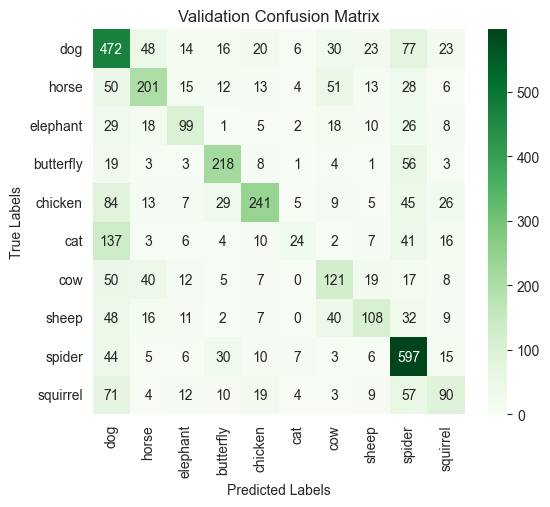

Validation Set Report
              precision    recall  f1-score   support

         dog       0.47      0.65      0.54       729
       horse       0.57      0.51      0.54       393
    elephant       0.54      0.46      0.49       216
   butterfly       0.67      0.69      0.68       316
     chicken       0.71      0.52      0.60       464
         cat       0.45      0.10      0.16       250
         cow       0.43      0.43      0.43       279
       sheep       0.54      0.40      0.46       273
      spider       0.61      0.83      0.70       723
    squirrel       0.44      0.32      0.37       279

    accuracy                           0.55      3922
   macro avg       0.54      0.49      0.50      3922
weighted avg       0.55      0.55      0.54      3922


Training Set Evaluation
573/573 [==============================] - 18s 31ms/step


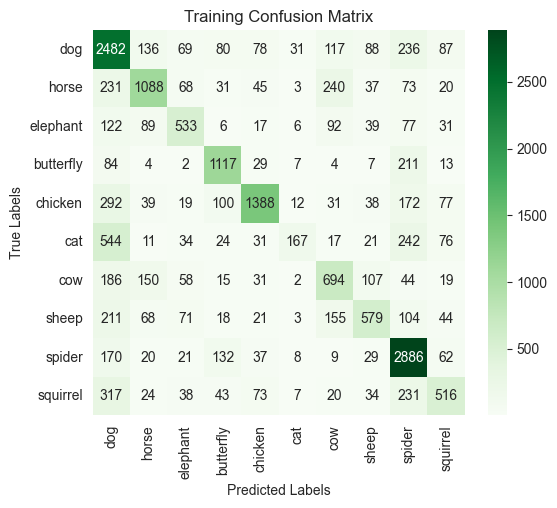

Training Set Report
              precision    recall  f1-score   support

         dog       0.54      0.73      0.62      3404
       horse       0.67      0.59      0.63      1836
    elephant       0.58      0.53      0.55      1012
   butterfly       0.71      0.76      0.73      1478
     chicken       0.79      0.64      0.71      2168
         cat       0.68      0.14      0.24      1167
         cow       0.50      0.53      0.52      1306
       sheep       0.59      0.45      0.51      1274
      spider       0.67      0.86      0.75      3374
    squirrel       0.55      0.40      0.46      1303

    accuracy                           0.62     18322
   macro avg       0.63      0.56      0.57     18322
weighted avg       0.63      0.62      0.61     18322



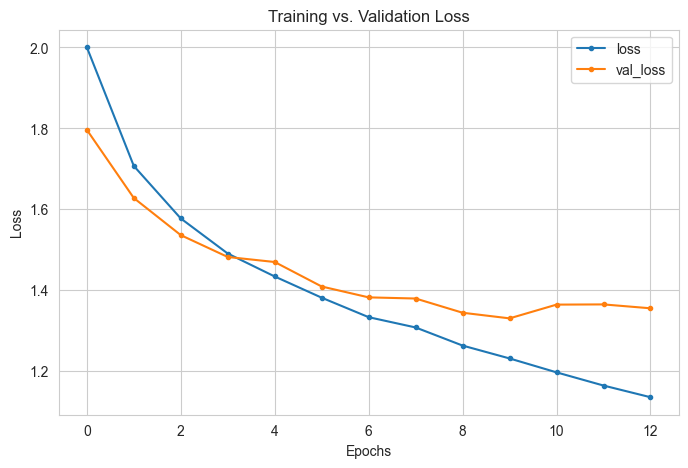

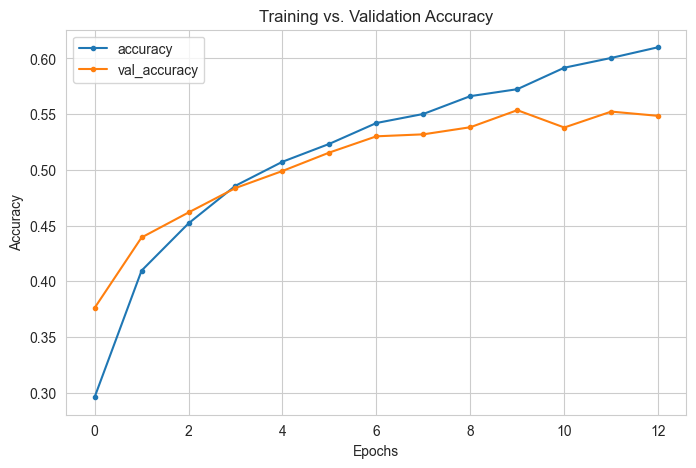

In [ ]:
import numpy as np          #Import the libraries needed for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loads and augments image data from folders 
from tensorflow.keras.models import Sequential # builds a neural netwrok layer by layer
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout # essential CNN building blocks 
from tensorflow.keras.callbacks import EarlyStopping # stops training when validation stops improving 
from sklearn.metrics import classification_report, confusion_matrix # model evaluation tools 

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # tf will show error messages only 
sns.set_style('white') # set plotting style 
img = (28,28) # resizes all images to 28x28
batch = 32 # model processes 32 images at a time before updating its weights 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # checks if a GPU is available for training and prints the number of GPUs found


datapath = r"C:\Mechanical engineering\Big Data\BigData\raw-img" #stores the location of he raw data set 
print("using dataset path:", datapath) 
print("Contents:", os.listdir(datapath)) # shows folder names inside the dataset 
output_folder = r"C:\Mechanical engineering\Big Data\BigData\output_images"
splitfolders.ratio(datapath, output=output_folder, seed=42, ratio=(.7, .15, .15)) # splits teh data set into 70% training, 15% validation and 15% test data, the seed ensures the split is reproducible


train_dir = r"C:\Mechanical engineering\Big Data\BigData\output_images\train" # defines folder locations
val_dir   = r"C:\Mechanical engineering\Big Data\BigData\output_images\val"  
test_dir  = r"C:\Mechanical engineering\Big Data\BigData\output_images\test"

def check_images(generator, dataset_name): # image validation function
  
    invalid_count = 0  # Counter for invalid images
    valid_count = 0    # Counter for valid images

    
    num_batches = len(generator)
    print(f"Checking {dataset_name} ({generator.n} total images across {num_batches} batches)...")

    for batch_idx in range(num_batches):
        images, _ = generator[batch_idx]
        
        for img_idx, image in enumerate(images):
            if not isinstance(image, np.ndarray):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Not a valid image array")
                invalid_count += 1
                continue

            if image.shape != (28, 28, 3):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Incorrect shape {image.shape}")
                invalid_count += 1
                continue

            if not (image.min() >= 0.0 and image.max() <= 1.0):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Invalid scaled pixel values (Min: {image.min()}, Max: {image.max()})")
                invalid_count += 1
                continue

            if np.isnan(image).any():
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Contains NaN values")
                invalid_count += 1
                continue

            valid_count += 1

    print(f"=== {dataset_name} Check Complete ===")
    print(f"Valid images: {valid_count} | Invalid images: {invalid_count}\n")
    




# converts pixel values from 0-255 to 0-1, this is important for training the model as it helps with convergence and stability during training.
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = val_test_datagen.flow_from_directory( # loads the images from the folders and applies the rescaling transformation defined above
    train_dir,
    target_size=img,
    batch_size=batch,
    class_mode='categorical', # multi-class classification, labels are one-hot encoded
    shuffle=True # preserves randomness in the training data order, which can help with generalization during training.
)
val_data = val_test_datagen.flow_from_directory( 
    val_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False # preserves the original order of the validation data, which is important for accurate evaluation and comparison of predictions against true labels.
)
test_data = val_test_datagen.flow_from_directory( 
    test_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)

check_images(train_data, "Train Set") # runs the image validation function on the training, validation and test data to ensure all images are correctly loaded and preprocessed before training the model.
check_images(val_data, "Validation Set")
check_images(test_data, "Test Set")

italian_to_english = { # the original file names are in italian, so they just need to be translated to English  
    "cane": "dog",
    "gatto": "cat",
    "cavallo": "horse",
    "ragno": "spider",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "pecora": "sheep",
    "mucca": "cow",
    "scoiattolo": "squirrel",
    "elefante": "elephant"
}
original_classes = list(train_data.class_indices.keys()) # gets class names in TF's internal order
class_names = [italian_to_english[c] for c in original_classes] # converts eacg class name to english while keeping the correct order
print("Classes:", class_names) # displays final class list

images, labels = next(train_data) # loads one batch of an array of images and one-hot encoded labels, this is used to visualize a sample image and its corresponding label to verify that the data loading and preprocessing steps are working correctly.
plt.imshow(images[0]) # shows first image in the batch
plt.title(f"Label: {class_names[np.argmax(labels[0])]}") # finds index of class, class name and one-hot vector.
plt.axis('off') # removes axes for cleaner display
plt.show() # renders the image

df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency']) # creates an empty table using pandas to store how many of each differnte label there is and which set they are in. 

def labelcount(generator, dataset_name): # defines a function to count the labels 
    global df_freq # globals the variable 
    counts = generator.classes # gives an array of class indices fo r all images 
    unique, frequency  = np.unique(counts, return_counts=True) # using numpy the code finds all distinct values and how often they appear 
     #creates a new one row data frame with: data set name, label name and frequency
    for u, f in zip(unique, frequency): # loops through class index and frequency
        df_freq = pd.concat([     # the concat adds the new row to df_freq
            df_freq,
            pd.DataFrame([{
                'Set': dataset_name,
                'Label': class_names[u], # converts numeric label to readable name 
                'Frequency': f
            }])
        ], ignore_index=True) # resets row numbering 

        print(f"* {dataset_name} - {class_names[u]}: {f}") # prints the information out  

labelcount(train_data, "Train") # counts label distribution in training set
labelcount(val_data, "Validation") # counts label distribution in validation set
labelcount(test_data,"Test") # counts label distribution in test set

# Graph to display the distributrion of each label and their frequency 
plt.figure(figsize=(10, 6)) # creates the plot
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label') # creartes the bar graph using seaborn
plt.xticks(rotation=45) # rotates labels by 45 degrees for ease of reading 
plt.title("Label Distribution") # the title 
plt.show() # render the graph 

def build_tf_model(input_shape, n_labels): # creates the neural network 
    model = Sequential()

    # First Convolutional Block 
    model.add(Conv2D(filters=16, kernel_size=(3, 3), input_shape=input_shape, activation='relu')) #learns 16 different filters to detect basic features like edges and textures, the kernel size of (3,3) means it looks at 3x3 pixel areas at a time, the activation function 'relu' helps the model learn complex patterns by introducing non-linearity.
    model.add(MaxPool2D(pool_size=(2, 2))) # reduces the image dimension by taking the maximum value in each 2x2 region 

    # Second Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu')) # learns 16 different filters
    model.add(MaxPool2D(pool_size=(2, 2)))

    # Flattening the feature maps, converts the 2D feature maps into a 1D vector  and prepares data for the dense layers
    model.add(Flatten())

    model.add(Dense(128, activation='relu')) # standard neural network layer, 128 neurons and it learns the combinations of extracted features.
    model.add(Dropout(0.25))  # Randomly turns off 25% of neurons during training to prevent overfitting by forcing the model to learn more robust features that are not reliant on specific neurons.

    model.add(Dense(n_labels, activation='softmax')) # produces probabilities for each class, softmax converts outputs into probabilities 
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # compiles the model with categorical crossentropy loss (suitable for multi-class classification), the Adam optimizer (An efficiency focused optimizer)), and tracks accuracy as a performance metric.

    return model

# Variables based on configuration
INPUT_SHAPE = (28, 28, 3)  
N_LABELS = len(class_names)

model = build_tf_model(INPUT_SHAPE, N_LABELS) # model is built using the function defined above with the specified input shape and number of labels/classes.
model.summary()

# this code is designed to train the model, while stopping when it stops improving 
model.summary() # printsa  table showing each layer, the output shapes and the number of parameters.  
early_stop = EarlyStopping(   # creates an early stopping object from keras, a callback is something that runs during training to monitor or modify behaviour 
    monitor='val_loss', # tells the model to watch validation loss (how wrong the model is on validation data)
    patience=3, # waits 3 epochs before stopping if no movement, prevents stopping too early due to small fluctuations. 
    restore_best_weights=True # after stopping it goes back to the best model, not the last one trained
)
history = model.fit( # starts training the neural network
    train_data,  # data used to learn patterns 
    validation_data=val_data, # data used to evaluate performance during training 
    epochs=20, # maximum number of training cycles 
    callbacks=[early_stop] # tells keras to use the early stopping rule during training
)


print("\nTest Set Evaluation")
predictions = model.predict(test_data) # generates predictions for the test data, which are probabilities for each class.
y_pred_test = np.argmax(predictions, axis=1) #chooses highest probability class as the predicted label for each image in the test set.
cm_test = confusion_matrix(test_data.classes, y_pred_test) # shows the correct and incorrect predictions for each class
#displayes the results as a confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()
print("Test Set Report")
print(classification_report( 
    test_data.classes,  
    y_pred_test, 
    target_names=class_names 
))

# Repeats the same process as above on the validation set
print("\nValidation Set Evaluation")
predictions_val = model.predict(val_data) 
y_pred_val = np.argmax(predictions_val, axis=1)
cm_val = confusion_matrix(val_data.classes, y_pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Validation Confusion Matrix")
plt.show()
print("Validation Set Report")
print(classification_report( 
    val_data.classes,  
    y_pred_val, 
    target_names=class_names 
))

train_eval_data = val_test_datagen.flow_from_directory( # because train_data is shuffled, a new generator that loads the training data without shuffling must be made to ensure the predictions are aligned with the true labels for accurate evaluation.
    train_dir,        
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)

# Repeats the same process as above on the Training set
print("\nTraining Set Evaluation")
predictions_train = model.predict(train_eval_data)
y_pred_train = np.argmax(predictions_train, axis=1)
cm_train = confusion_matrix(train_eval_data.classes, y_pred_train)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Training Confusion Matrix")
plt.show()
print("Training Set Report")
print(classification_report( 
    train_data.classes,  
    y_pred_train, 
    target_names=class_names 
))


history_df = pd.DataFrame(history.history) # stores the training history (loss and accuracy for each epoch) in a DataFrame for easier plotting and analysis.
sns.set_style("whitegrid")
history_df[['loss', 'val_loss']].plot(style='.-', figsize=(8, 5)) # plots the training and validation loss curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print("\n")
history_df[['accuracy', 'val_accuracy']].plot(style='.-', figsize=(8, 5)) # plots the training and validation accuracy curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()






# Version 2
### 64,64 image resolution
### 32 batch size 
### 32 and 64 filter model 

Increasing the image size and convolution layer filters has increased the test accuracy from 56% to 62%, the validation accuracy to 61% and the training accuracy has reached 82%. The cat accuracy has also increased to 24%. All this means that th changes were positive and that the model is moving in the right direction. 

The problem now is overfitting, the model is now memorising the data set as opposed to learning the general traits of each animal needed to identify them. Around epoch 3-5 the training loss keeps dropping toward 0.6, however the validation loss bottoms out at 1.16 and then starts climbing back up. The training and validation accuracy shows a similar story,with training at 82% while validation is only at 62%

The next iteration to combat these problems I will introduce a 3rd convolution layer to aid in picking out finer details, the training set data will also show the model images from many different angles to prevent it from memorising the data set. 

Num GPUs Available:  2
using dataset path: C:\Mechanical engineering\Big Data\BigData\raw-img
Contents: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.
Checking Train Set (18322 total images across 573 batches)...
=== Train Set Check Complete ===
Valid images: 18322 | Invalid images: 0

Checking Validation Set (3922 total images across 123 batches)...
=== Validation Set Check Complete ===
Valid images: 3922 | Invalid images: 0

Checking Test Set (3935 total images across 123 batches)...
=== Test Set Check Complete ===
Valid images: 3935 | Invalid images: 0

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


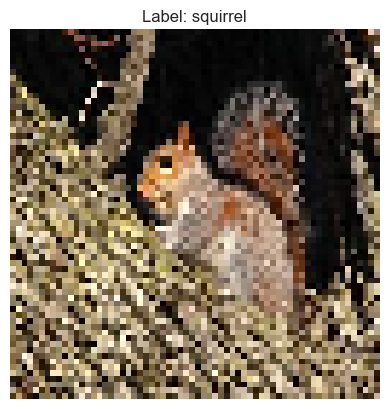

* Train - dog: 3404
* Train - horse: 1836
* Train - elephant: 1012
* Train - butterfly: 1478
* Train - chicken: 2168
* Train - cat: 1167
* Train - cow: 1306
* Train - sheep: 1274
* Train - spider: 3374
* Train - squirrel: 1303
* Validation - dog: 729
* Validation - horse: 393
* Validation - elephant: 216
* Validation - butterfly: 316
* Validation - chicken: 464
* Validation - cat: 250
* Validation - cow: 279
* Validation - sheep: 273
* Validation - spider: 723
* Validation - squirrel: 279
* Test - dog: 730
* Test - horse: 394
* Test - elephant: 218
* Test - butterfly: 318
* Test - chicken: 466
* Test - cat: 251
* Test - cow: 281
* Test - sheep: 273
* Test - spider: 724
* Test - squirrel: 280


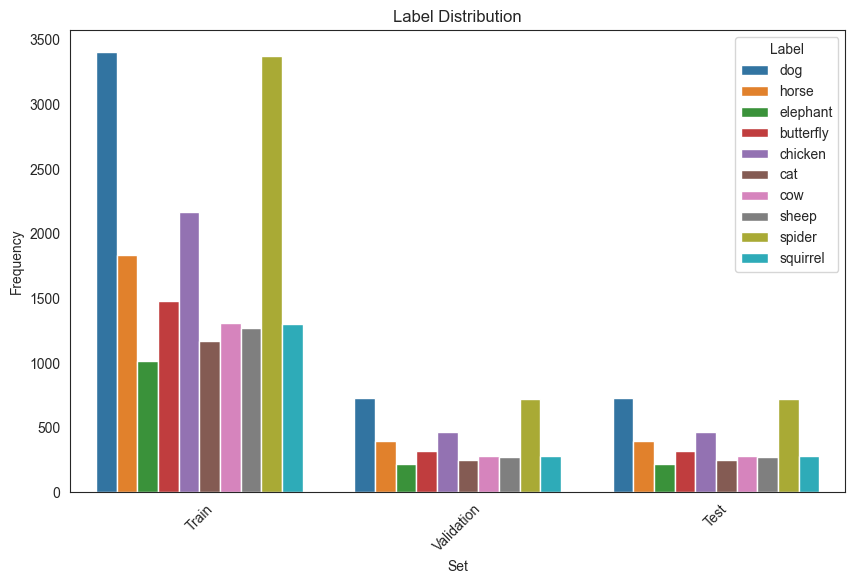

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_56 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_56 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_57 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_57 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 flatten_22 (Flatten)        (None, 12544)             0         
                                                                 
 dense_44 (Dense)            (None, 128)             

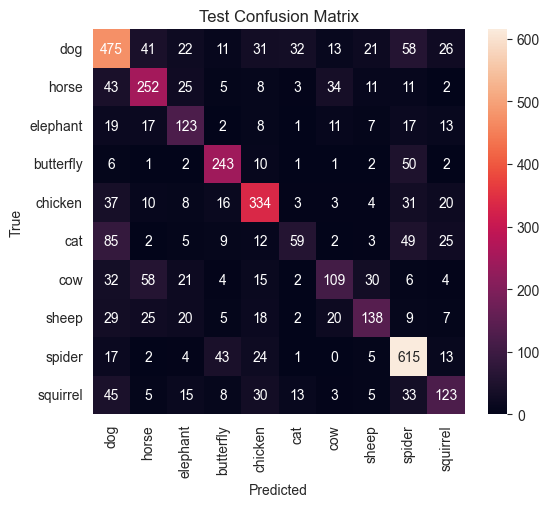

Test Set Report
              precision    recall  f1-score   support

         dog       0.60      0.65      0.63       730
       horse       0.61      0.64      0.62       394
    elephant       0.50      0.56      0.53       218
   butterfly       0.70      0.76      0.73       318
     chicken       0.68      0.72      0.70       466
         cat       0.50      0.24      0.32       251
         cow       0.56      0.39      0.46       281
       sheep       0.61      0.51      0.55       273
      spider       0.70      0.85      0.77       724
    squirrel       0.52      0.44      0.48       280

    accuracy                           0.63      3935
   macro avg       0.60      0.58      0.58      3935
weighted avg       0.62      0.63      0.62      3935


Validation Set Evaluation
123/123 [==============================] - 5s 37ms/step


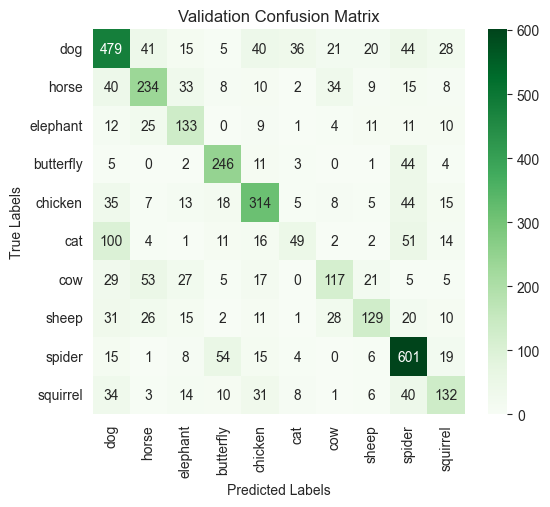

Validation Set Report
              precision    recall  f1-score   support

         dog       0.61      0.66      0.63       729
       horse       0.59      0.60      0.59       393
    elephant       0.51      0.62      0.56       216
   butterfly       0.69      0.78      0.73       316
     chicken       0.66      0.68      0.67       464
         cat       0.45      0.20      0.27       250
         cow       0.54      0.42      0.47       279
       sheep       0.61      0.47      0.53       273
      spider       0.69      0.83      0.75       723
    squirrel       0.54      0.47      0.50       279

    accuracy                           0.62      3922
   macro avg       0.59      0.57      0.57      3922
weighted avg       0.61      0.62      0.61      3922

Found 18322 images belonging to 10 classes.

Training Set Evaluation
573/573 [==============================] - 23s 40ms/step


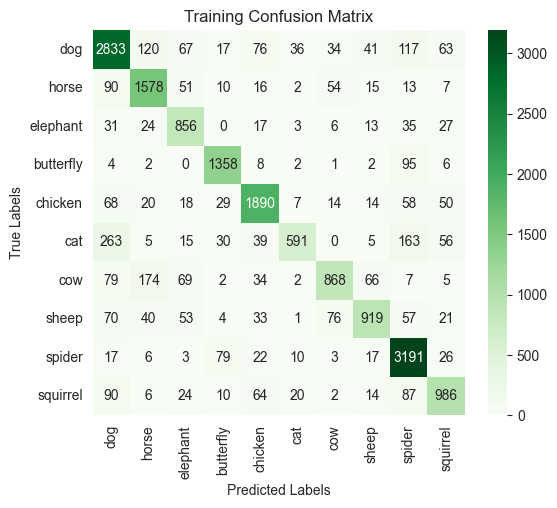

Training Set Report
              precision    recall  f1-score   support

         dog       0.80      0.83      0.82      3404
       horse       0.80      0.86      0.83      1836
    elephant       0.74      0.85      0.79      1012
   butterfly       0.88      0.92      0.90      1478
     chicken       0.86      0.87      0.87      2168
         cat       0.88      0.51      0.64      1167
         cow       0.82      0.66      0.73      1306
       sheep       0.83      0.72      0.77      1274
      spider       0.83      0.95      0.89      3374
    squirrel       0.79      0.76      0.77      1303

    accuracy                           0.82     18322
   macro avg       0.82      0.79      0.80     18322
weighted avg       0.82      0.82      0.82     18322



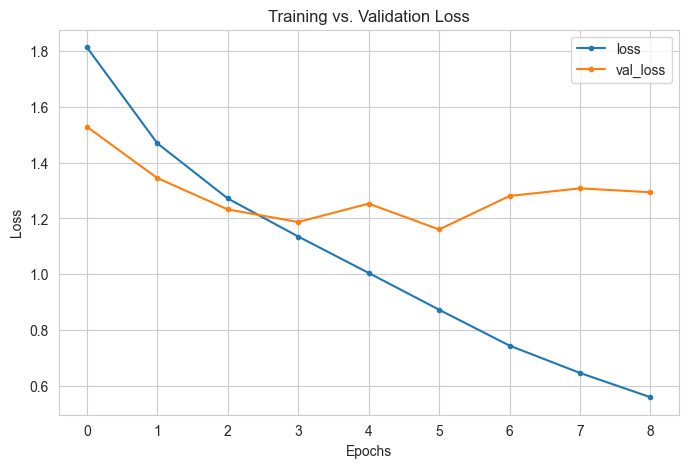

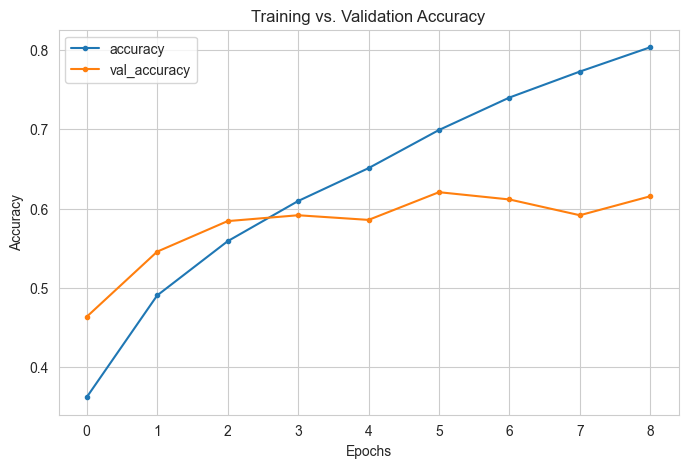

In [33]:
import numpy as np          #Import the libraries needed for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loads and augments image data from folders 
from tensorflow.keras.models import Sequential # builds a neural netwrok layer by layer
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout # essential CNN building blocks 
from tensorflow.keras.callbacks import EarlyStopping # stops training when validation stops improving 
from sklearn.metrics import classification_report, confusion_matrix # model evaluation tools 

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # tf will show error messages only 
sns.set_style('white') # set plotting style 
img = (64, 64) # resizes all images to 64x64
batch = 32 # model processes 32 images at a time before updating its weights 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # checks if a GPU is available for training and prints the number of GPUs found


datapath = r"C:\Mechanical engineering\Big Data\BigData\raw-img" #stores the location of he raw data set 
print("using dataset path:", datapath) 
print("Contents:", os.listdir(datapath)) # shows folder names inside the dataset 
output_folder = r"C:\Mechanical engineering\Big Data\BigData\output_images"
splitfolders.ratio(datapath, output=output_folder, seed=42, ratio=(.7, .15, .15)) # splits teh data set into 70% training, 15% validation and 15% test data, the seed ensures the split is reproducible


train_dir = r"C:\Mechanical engineering\Big Data\BigData\output_images\train" # defines folder locations
val_dir   = r"C:\Mechanical engineering\Big Data\BigData\output_images\val"  
test_dir  = r"C:\Mechanical engineering\Big Data\BigData\output_images\test"

def check_images(generator, dataset_name): # image validation function
  
    invalid_count = 0  # Counter for invalid images
    valid_count = 0    # Counter for valid images

    
    num_batches = len(generator)
    print(f"Checking {dataset_name} ({generator.n} total images across {num_batches} batches)...")

    for batch_idx in range(num_batches):
        images, _ = generator[batch_idx]
        
        for img_idx, image in enumerate(images):
            if not isinstance(image, np.ndarray):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Not a valid image array")
                invalid_count += 1
                continue

            if image.shape != (64, 64, 3):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Incorrect shape {image.shape}")
                invalid_count += 1
                continue

            if not (image.min() >= 0.0 and image.max() <= 1.0):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Invalid scaled pixel values (Min: {image.min()}, Max: {image.max()})")
                invalid_count += 1
                continue

            if np.isnan(image).any():
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Contains NaN values")
                invalid_count += 1
                continue

            valid_count += 1

    print(f"=== {dataset_name} Check Complete ===")
    print(f"Valid images: {valid_count} | Invalid images: {invalid_count}\n")
    


# converts pixel values from 0-255 to 0-1, this is important for training the model as it helps with convergence and stability during training.
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = val_test_datagen.flow_from_directory( # loads the images from the folders and applies the rescaling transformation defined above
    train_dir,
    target_size=img,
    batch_size=batch,
    class_mode='categorical', # multi-class classification, labels are one-hot encoded
    shuffle=True # preserves randomness in the training data order, which can help with generalization during training.
)
val_data = val_test_datagen.flow_from_directory( 
    val_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False # preserves the original order of the validation data, which is important for accurate evaluation and comparison of predictions against true labels.
)
test_data = val_test_datagen.flow_from_directory( 
    test_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)

check_images(train_data, "Train Set") # runs the image validation function on the training, validation and test data to ensure all images are correctly loaded and preprocessed before training the model.
check_images(val_data, "Validation Set")
check_images(test_data, "Test Set")

italian_to_english = { # the original file names are in italian, so they just need to be translated to English  
    "cane": "dog",
    "gatto": "cat",
    "cavallo": "horse",
    "ragno": "spider",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "pecora": "sheep",
    "mucca": "cow",
    "scoiattolo": "squirrel",
    "elefante": "elephant"
}
original_classes = list(train_data.class_indices.keys()) # gets class names in TF's internal order
class_names = [italian_to_english[c] for c in original_classes] # converts eacg class name to english while keeping the correct order
print("Classes:", class_names) # displays final class list

images, labels = next(train_data) # loads one batch of an array of images and one-hot encoded labels, this is used to visualize a sample image and its corresponding label to verify that the data loading and preprocessing steps are working correctly.
plt.imshow(images[0]) # shows first image in the batch
plt.title(f"Label: {class_names[np.argmax(labels[0])]}") # finds index of class, class name and one-hot vector.
plt.axis('off') # removes axes for cleaner display
plt.show() # renders the image

df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency']) # creates an empty table using pandas to store how many of each differnte label there is and which set they are in. 

def labelcount(generator, dataset_name): # defines a function to count the labels 
    global df_freq # globals the variable 
    counts = generator.classes # gives an array of class indices fo r all images 
    unique, frequency  = np.unique(counts, return_counts=True) # using numpy the code finds all distinct values and how often they appear 
     #creates a new one row data frame with: data set name, label name and frequency
    for u, f in zip(unique, frequency): # loops through class index and frequency
        df_freq = pd.concat([     # the concat adds the new row to df_freq
            df_freq,
            pd.DataFrame([{
                'Set': dataset_name,
                'Label': class_names[u], # converts numeric label to readable name 
                'Frequency': f
            }])
        ], ignore_index=True) # resets row numbering 

        print(f"* {dataset_name} - {class_names[u]}: {f}") # prints the information out  

labelcount(train_data, "Train") # counts label distribution in training set
labelcount(val_data, "Validation") # counts label distribution in validation set
labelcount(test_data,"Test") # counts label distribution in test set

# Graph to display the distributrion of each label and their frequency 
plt.figure(figsize=(10, 6)) # creates the plot
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label') # creartes the bar graph using seaborn
plt.xticks(rotation=45) # rotates labels by 45 degrees for ease of reading 
plt.title("Label Distribution") # the title 
plt.show() # render the graph 

def build_tf_model(input_shape, n_labels): # creates the neural network 
    model = Sequential()

    # First Convolutional Block 
    model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=input_shape, activation='relu')) #learns 32 different filters to detect basic features like edges and textures, the kernel size of (3,3) means it looks at 3x3 pixel areas at a time, the activation function 'relu' helps the model learn complex patterns by introducing non-linearity.
    model.add(MaxPool2D(pool_size=(2, 2))) # reduces the image dimension by taking the maximum value in each 2x2 region 

    # Second Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(MaxPool2D(pool_size=(2, 2)))

    # Flattening the feature maps, converts the 2D feature maps into a 1D vector  and prepares data for the dense layers
    model.add(Flatten())

    model.add(Dense(128, activation='relu')) # standard neural network layer, 128 neurons and it learns the combinations of extracted features.
    model.add(Dropout(0.25))  # Randomly turns off 25% of neurons during training to prevent overfitting by forcing the model to learn more robust features that are not reliant on specific neurons.

    model.add(Dense(n_labels, activation='softmax')) # produces probabilities for each class, softmax converts outputs into probabilities 
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # compiles the model with categorical crossentropy loss (suitable for multi-class classification), the Adam optimizer (An efficiency focused optimizer)), and tracks accuracy as a performance metric.

    return model

# Variables based on configuration
INPUT_SHAPE = (64, 64, 3)  
N_LABELS = len(class_names)

model = build_tf_model(INPUT_SHAPE, N_LABELS) # model is built using the function defined above with the specified input shape and number of labels/classes.
model.summary()

# this code is designed to train the model, while stopping when it stops improving 
model.summary() # printsa  table showing each layer, the output shapes and the number of parameters.  
early_stop = EarlyStopping(   # creates an early stopping object from keras, a callback is something that runs during training to monitor or modify behaviour 
    monitor='val_loss', # tells the model to watch validation loss (how wrong the model is on validation data)
    patience=3, # waits 3 epochs before stopping if no movement, prevents stopping too early due to small fluctuations. 
    restore_best_weights=True # after stopping it goes back to the best model, not the last one trained
)
history = model.fit( # starts training the neural network
    train_data,  # data used to learn patterns 
    validation_data=val_data, # data used to evaluate performance during training 
    epochs=20, # maximum number of training cycles 
    callbacks=[early_stop] # tells keras to use the early stopping rule during training
)


print("\nTest Set Evaluation")
predictions = model.predict(test_data) # generates predictions for the test data, which are probabilities for each class.
y_pred_test = np.argmax(predictions, axis=1) #chooses highest probability class as the predicted label for each image in the test set.
cm_test = confusion_matrix(test_data.classes, y_pred_test) # shows the correct and incorrect predictions for each class
#displayes the results as a confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()
print("Test Set Report")
print(classification_report( 
    test_data.classes,  
    y_pred_test, 
    target_names=class_names 
))

# Repeats the same process as above on the validation set
print("\nValidation Set Evaluation")
predictions_val = model.predict(val_data) 
y_pred_val = np.argmax(predictions_val, axis=1)
cm_val = confusion_matrix(val_data.classes, y_pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Validation Confusion Matrix")
plt.show()
print("Validation Set Report")
print(classification_report( 
    val_data.classes,  
    y_pred_val, 
    target_names=class_names 
))

train_eval_data = val_test_datagen.flow_from_directory( # because train_data is shuffled, a new generator that loads the training data without shuffling must be made to ensure the predictions are aligned with the true labels for accurate evaluation.
    train_dir,        
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)


# Repeats the same process as above on the Training set
print("\nTraining Set Evaluation")
predictions_train = model.predict(train_eval_data)
y_pred_train = np.argmax(predictions_train, axis=1)
cm_train = confusion_matrix(train_eval_data.classes, y_pred_train)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Training Confusion Matrix")
plt.show()
print("Training Set Report")
print(classification_report( 
    train_data.classes,  
    y_pred_train, 
    target_names=class_names 
))


history_df = pd.DataFrame(history.history) # stores the training history (loss and accuracy for each epoch) in a DataFrame for easier plotting and analysis.
sns.set_style("whitegrid")
history_df[['loss', 'val_loss']].plot(style='.-', figsize=(8, 5)) # plots the training and validation loss curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print("\n")
history_df[['accuracy', 'val_accuracy']].plot(style='.-', figsize=(8, 5)) # plots the training and validation accuracy curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()






# Version 3
### 64,64 image resolution
### 32 batch size 
### 32 and 64 and 128 filter model
### Patience increased to 5
### Also added a training generator to change th viewing angles of the images
### Batch normalisation was added

All the changes have increased the model's accuracy: The training has reached 69%, the validation 64% and the test 65%. 
These values indicate that the model being used is in a healthy position and that the changes made have had a positive impact. Having such a small gap between the training and test accuracy indicates that the model is learning the features of the animals and not memorising the dataset itself like previous iterations. 


At this stage the main bottleneck preventing higher accuracy is likely the image quality, at the current level of detail one 4 legged animal likely looks practically identical to another. The next iteration will increase it to 128 to help make finer details more obvious to help distinguish physiologically similar animals.

Num GPUs Available:  2
using dataset path: C:\Mechanical engineering\Big Data\BigData\raw-img
Contents: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.
Checking Train Set (18322 total images across 573 batches)...
=== Train Set Check Complete ===
Valid images: 18322 | Invalid images: 0

Checking Validation Set (3922 total images across 123 batches)...
=== Validation Set Check Complete ===
Valid images: 3922 | Invalid images: 0

Checking Test Set (3935 total images across 123 batches)...
=== Test Set Check Complete ===
Valid images: 3935 | Invalid images: 0

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


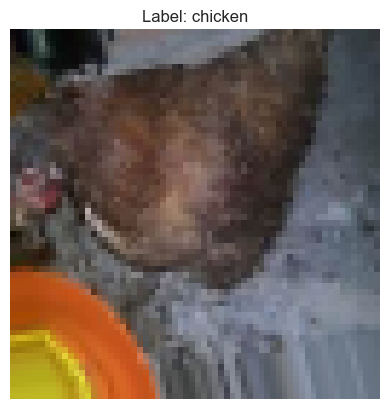

* Train - dog: 3404
* Train - horse: 1836
* Train - elephant: 1012
* Train - butterfly: 1478
* Train - chicken: 2168
* Train - cat: 1167
* Train - cow: 1306
* Train - sheep: 1274
* Train - spider: 3374
* Train - squirrel: 1303
* Validation - dog: 729
* Validation - horse: 393
* Validation - elephant: 216
* Validation - butterfly: 316
* Validation - chicken: 464
* Validation - cat: 250
* Validation - cow: 279
* Validation - sheep: 273
* Validation - spider: 723
* Validation - squirrel: 279
* Test - dog: 730
* Test - horse: 394
* Test - elephant: 218
* Test - butterfly: 318
* Test - chicken: 466
* Test - cat: 251
* Test - cow: 281
* Test - sheep: 273
* Test - spider: 724
* Test - squirrel: 280


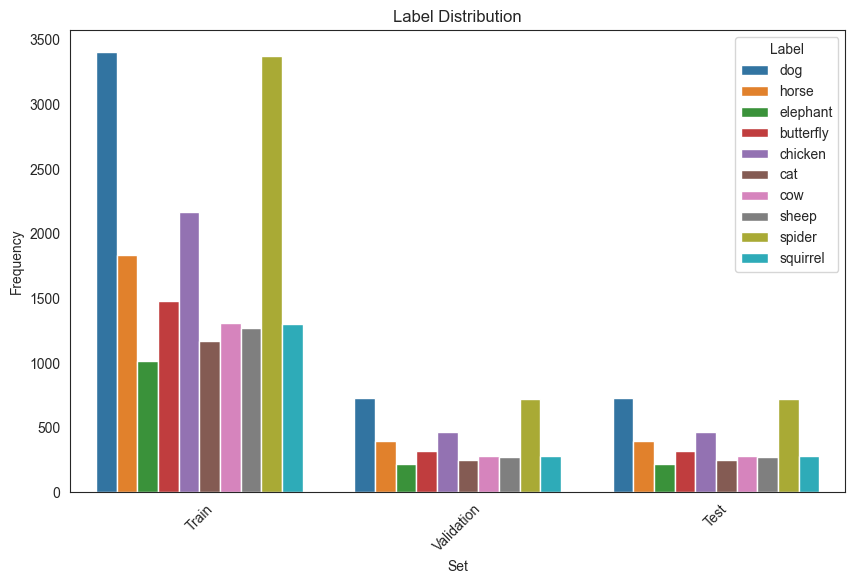

Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_61 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 62, 62, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d_61 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_62 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 29, 29, 64)       256       
 hNormalization)                                                 
                                                     

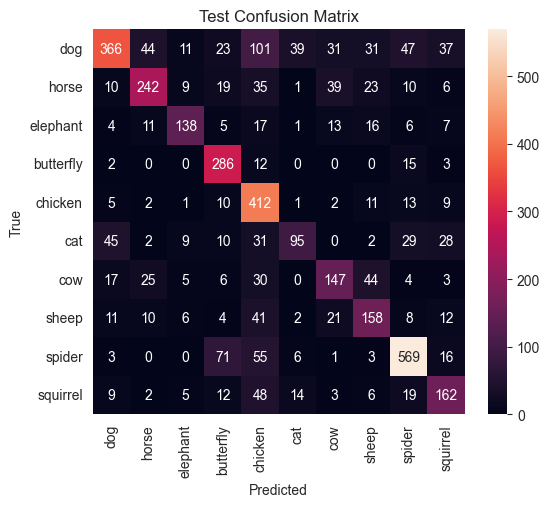

Test Set Report
              precision    recall  f1-score   support

         dog       0.78      0.50      0.61       730
       horse       0.72      0.61      0.66       394
    elephant       0.75      0.63      0.69       218
   butterfly       0.64      0.90      0.75       318
     chicken       0.53      0.88      0.66       466
         cat       0.60      0.38      0.46       251
         cow       0.57      0.52      0.55       281
       sheep       0.54      0.58      0.56       273
      spider       0.79      0.79      0.79       724
    squirrel       0.57      0.58      0.58       280

    accuracy                           0.65      3935
   macro avg       0.65      0.64      0.63      3935
weighted avg       0.67      0.65      0.65      3935


Validation Set Evaluation
123/123 [==============================] - 5s 41ms/step


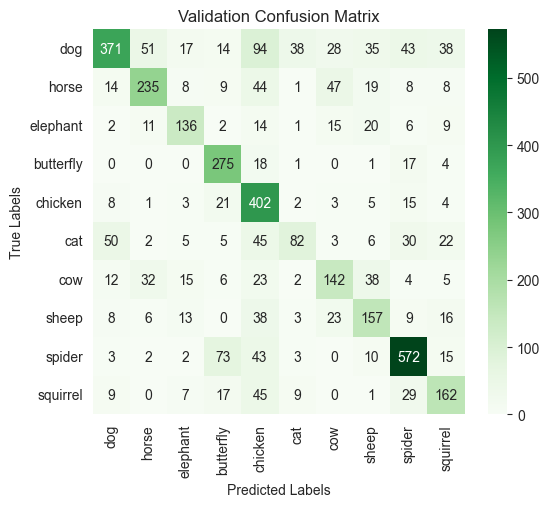

Validation Set Report
              precision    recall  f1-score   support

         dog       0.78      0.51      0.62       729
       horse       0.69      0.60      0.64       393
    elephant       0.66      0.63      0.64       216
   butterfly       0.65      0.87      0.75       316
     chicken       0.52      0.87      0.65       464
         cat       0.58      0.33      0.42       250
         cow       0.54      0.51      0.53       279
       sheep       0.54      0.58      0.56       273
      spider       0.78      0.79      0.79       723
    squirrel       0.57      0.58      0.58       279

    accuracy                           0.65      3922
   macro avg       0.63      0.63      0.62      3922
weighted avg       0.66      0.65      0.64      3922

Found 18322 images belonging to 10 classes.

Training Set Evaluation
573/573 [==============================] - 26s 45ms/step


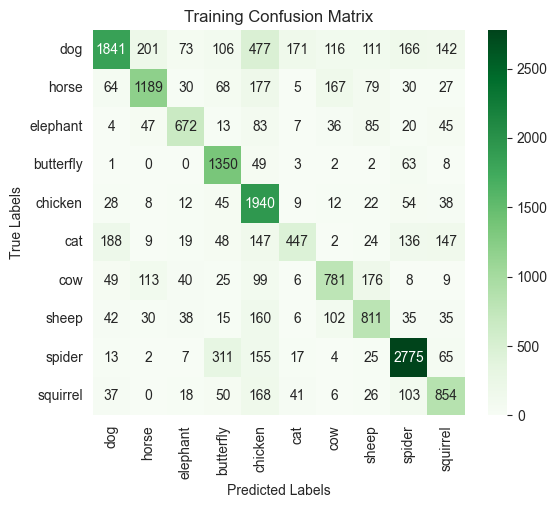

Training Set Report
              precision    recall  f1-score   support

         dog       0.81      0.54      0.65      3404
       horse       0.74      0.65      0.69      1836
    elephant       0.74      0.66      0.70      1012
   butterfly       0.66      0.91      0.77      1478
     chicken       0.56      0.89      0.69      2168
         cat       0.63      0.38      0.48      1167
         cow       0.64      0.60      0.62      1306
       sheep       0.60      0.64      0.62      1274
      spider       0.82      0.82      0.82      3374
    squirrel       0.62      0.66      0.64      1303

    accuracy                           0.69     18322
   macro avg       0.68      0.68      0.67     18322
weighted avg       0.71      0.69      0.69     18322



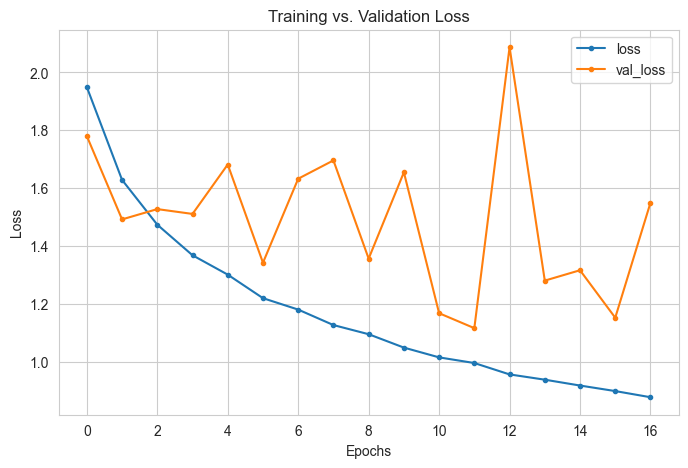

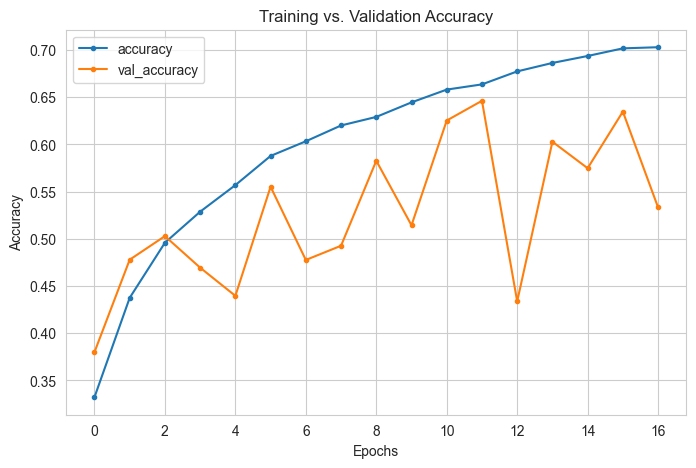

In [36]:
import numpy as np          #Import the libraries needed for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loads and augments image data from folders 
from tensorflow.keras.models import Sequential # builds a neural netwrok layer by layer
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout # essential CNN building blocks 
from tensorflow.keras.callbacks import EarlyStopping # stops training when validation stops improving 
from sklearn.metrics import classification_report, confusion_matrix # model evaluation tools 

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # tf will show error messages only 
sns.set_style('white') # set plotting style 
img = (64, 64) # resizes all images to 64x64
batch = 32 # model processes 32 images at a time before updating its weights 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # checks if a GPU is available for training and prints the number of GPUs found


datapath = r"C:\Mechanical engineering\Big Data\BigData\raw-img" #stores the location of he raw data set 
print("using dataset path:", datapath) 
print("Contents:", os.listdir(datapath)) # shows folder names inside the dataset 
output_folder = r"C:\Mechanical engineering\Big Data\BigData\output_images"
splitfolders.ratio(datapath, output=output_folder, seed=42, ratio=(.7, .15, .15)) # splits teh data set into 70% training, 15% validation and 15% test data, the seed ensures the split is reproducible


train_dir = r"C:\Mechanical engineering\Big Data\BigData\output_images\train" # defines folder locations
val_dir   = r"C:\Mechanical engineering\Big Data\BigData\output_images\val"  
test_dir  = r"C:\Mechanical engineering\Big Data\BigData\output_images\test"

def check_images(generator, dataset_name): # image validation function
  
    invalid_count = 0  # Counter for invalid images
    valid_count = 0    # Counter for valid images

    
    num_batches = len(generator)
    print(f"Checking {dataset_name} ({generator.n} total images across {num_batches} batches)...")

    for batch_idx in range(num_batches):
        images, _ = generator[batch_idx]
        
        for img_idx, image in enumerate(images):
            if not isinstance(image, np.ndarray):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Not a valid image array")
                invalid_count += 1
                continue

            if image.shape != (64, 64, 3):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Incorrect shape {image.shape}")
                invalid_count += 1
                continue

            if not (image.min() >= 0.0 and image.max() <= 1.0):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Invalid scaled pixel values (Min: {image.min()}, Max: {image.max()})")
                invalid_count += 1
                continue

            if np.isnan(image).any():
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Contains NaN values")
                invalid_count += 1
                continue

            valid_count += 1

    print(f"=== {dataset_name} Check Complete ===")
    print(f"Valid images: {valid_count} | Invalid images: {invalid_count}\n")
    

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,      # Randomly rotate images up to 15 degrees
    width_shift_range=0.1,  # Randomly translate horizontally
    height_shift_range=0.1, # Randomly translate vertically
    shear_range=0.1,        # Apply shearing transformations
    zoom_range=0.1,         # Randomly zoom inside pictures
    horizontal_flip=True,   # Flip images horizontally
    fill_mode='nearest'
)

# converts pixel values from 0-255 to 0-1, this is important for training the model as it helps with convergence and stability during training.
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory( # loads the images from the folders and applies the rescaling transformation defined above
    train_dir,
    target_size=img,
    batch_size=batch,
    class_mode='categorical', # multi-class classification, labels are one-hot encoded
    shuffle=True # preserves randomness in the training data order, which can help with generalization during training.
)
val_data = val_test_datagen.flow_from_directory( 
    val_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False # preserves the original order of the validation data, which is important for accurate evaluation and comparison of predictions against true labels.
)
test_data = val_test_datagen.flow_from_directory( 
    test_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)

check_images(train_data, "Train Set") # runs the image validation function on the training, validation and test data to ensure all images are correctly loaded and preprocessed before training the model.
check_images(val_data, "Validation Set")
check_images(test_data, "Test Set")

italian_to_english = { # the original file names are in italian, so they just need to be translated to English  
    "cane": "dog",
    "gatto": "cat",
    "cavallo": "horse",
    "ragno": "spider",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "pecora": "sheep",
    "mucca": "cow",
    "scoiattolo": "squirrel",
    "elefante": "elephant"
}
original_classes = list(train_data.class_indices.keys()) # gets class names in TF's internal order
class_names = [italian_to_english[c] for c in original_classes] # converts eacg class name to english while keeping the correct order
print("Classes:", class_names) # displays final class list

images, labels = next(train_data) # loads one batch of an array of images and one-hot encoded labels, this is used to visualize a sample image and its corresponding label to verify that the data loading and preprocessing steps are working correctly.
plt.imshow(images[0]) # shows first image in the batch
plt.title(f"Label: {class_names[np.argmax(labels[0])]}") # finds index of class, class name and one-hot vector.
plt.axis('off') # removes axes for cleaner display
plt.show() # renders the image

df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency']) # creates an empty table using pandas to store how many of each differnte label there is and which set they are in. 

def labelcount(generator, dataset_name): # defines a function to count the labels 
    global df_freq # globals the variable 
    counts = generator.classes # gives an array of class indices fo r all images 
    unique, frequency  = np.unique(counts, return_counts=True) # using numpy the code finds all distinct values and how often they appear 
     #creates a new one row data frame with: data set name, label name and frequency
    for u, f in zip(unique, frequency): # loops through class index and frequency
        df_freq = pd.concat([     # the concat adds the new row to df_freq
            df_freq,
            pd.DataFrame([{
                'Set': dataset_name,
                'Label': class_names[u], # converts numeric label to readable name 
                'Frequency': f
            }])
        ], ignore_index=True) # resets row numbering 

        print(f"* {dataset_name} - {class_names[u]}: {f}") # prints the information out  

labelcount(train_data, "Train") # counts label distribution in training set
labelcount(val_data, "Validation") # counts label distribution in validation set
labelcount(test_data,"Test") # counts label distribution in test set

# Graph to display the distributrion of each label and their frequency 
plt.figure(figsize=(10, 6)) # creates the plot
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label') # creartes the bar graph using seaborn
plt.xticks(rotation=45) # rotates labels by 45 degrees for ease of reading 
plt.title("Label Distribution") # the title 
plt.show() # render the graph 

def build_tf_model(input_shape, n_labels): # creates the neural network 
    model = Sequential()

    # First Convolutional Block 
    model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=input_shape, activation='relu')) #learns 32 different filters to detect basic features like edges and textures, the kernel size of (3,3) means it looks at 3x3 pixel areas at a time, the activation function 'relu' helps the model learn complex patterns by introducing non-linearity.
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2))) # reduces the image dimension by taking the maximum value in each 2x2 region 

    # Second Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
     # Third Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    # Flattening the feature maps, converts the 2D feature maps into a 1D vector  and prepares data for the dense layers
    model.add(Flatten())

    model.add(Dense(128, activation='relu')) # standard neural network layer, 128 neurons and it learns the combinations of extracted features.
    model.add(Dropout(0.25))  # Randomly turns off 25% of neurons during training to prevent overfitting by forcing the model to learn more robust features that are not reliant on specific neurons.

    model.add(Dense(n_labels, activation='softmax')) # produces probabilities for each class, softmax converts outputs into probabilities 
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # compiles the model with categorical crossentropy loss (suitable for multi-class classification), the Adam optimizer (An efficiency focused optimizer)), and tracks accuracy as a performance metric.

    return model

# Variables based on configuration
INPUT_SHAPE = (64, 64, 3)  
N_LABELS = len(class_names)

model = build_tf_model(INPUT_SHAPE, N_LABELS) # model is built using the function defined above with the specified input shape and number of labels/classes.
model.summary()

# this code is designed to train the model, while stopping when it stops improving 
model.summary() # printsa  table showing each layer, the output shapes and the number of parameters.  
early_stop = EarlyStopping(   # creates an early stopping object from keras, a callback is something that runs during training to monitor or modify behaviour 
    monitor='val_loss', # tells the model to watch validation loss (how wrong the model is on validation data)
    patience=5, # waits 3 epochs before stopping if no movement, prevents stopping too early due to small fluctuations. 
    restore_best_weights=True # after stopping it goes back to the best model, not the last one trained
)
history = model.fit( # starts training the neural network
    train_data,  # data used to learn patterns 
    validation_data=val_data, # data used to evaluate performance during training 
    epochs=20, # maximum number of training cycles 
    callbacks=[early_stop] # tells keras to use the early stopping rule during training
)


print("\nTest Set Evaluation")
predictions = model.predict(test_data) # generates predictions for the test data, which are probabilities for each class.
y_pred_test = np.argmax(predictions, axis=1) #chooses highest probability class as the predicted label for each image in the test set.
cm_test = confusion_matrix(test_data.classes, y_pred_test) # shows the correct and incorrect predictions for each class
#displayes the results as a confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()
print("Test Set Report")
print(classification_report( 
    test_data.classes,  
    y_pred_test, 
    target_names=class_names 
))

# Repeats the same process as above on the validation set
print("\nValidation Set Evaluation")
predictions_val = model.predict(val_data) 
y_pred_val = np.argmax(predictions_val, axis=1)
cm_val = confusion_matrix(val_data.classes, y_pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Validation Confusion Matrix")
plt.show()
print("Validation Set Report")
print(classification_report( 
    val_data.classes,  
    y_pred_val, 
    target_names=class_names 
))

train_eval_data = val_test_datagen.flow_from_directory( # because train_data is shuffled, a new generator that loads the training data without shuffling must be made to ensure the predictions are aligned with the true labels for accurate evaluation.
    train_dir,        
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)


# Repeats the same process as above on the Training set
print("\nTraining Set Evaluation")
predictions_train = model.predict(train_eval_data)
y_pred_train = np.argmax(predictions_train, axis=1)
cm_train = confusion_matrix(train_eval_data.classes, y_pred_train)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Training Confusion Matrix")
plt.show()
print("Training Set Report")
print(classification_report( 
    train_eval_data.classes,  
    y_pred_train, 
    target_names=class_names 
))


history_df = pd.DataFrame(history.history) # stores the training history (loss and accuracy for each epoch) in a DataFrame for easier plotting and analysis.
sns.set_style("whitegrid")
history_df[['loss', 'val_loss']].plot(style='.-', figsize=(8, 5)) # plots the training and validation loss curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print("\n")
history_df[['accuracy', 'val_accuracy']].plot(style='.-', figsize=(8, 5)) # plots the training and validation accuracy curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()






# Version 4
### 128,128 image resolution
### batch size 32
### 32, 64 and 128 filter model 
### patience 5 

Unfortunately it seems adding resolution and increasing the image size to 128,128 has had the opposite effect of what was intended. The training accuracy has dropped down to 50%, the validation down to 48% and the test down to 49%. 

The massive increase in trainable connections means the dense layer cannot map out the logic correctly, with so many parameters and a small dataset the model either overfits or stalls out. A 3 layer network using small 3x3 filters can see a large percentage of a 64x64 at once, however for a 128,128 the layers are too shallow. 

Therefore a 4th convolution layer will be added and the neuron density increased to 256 to help map out the increased number of trainable connections

Num GPUs Available:  2
using dataset path: C:\Mechanical engineering\Big Data\BigData\raw-img
Contents: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.
Checking Train Set (18322 total images across 573 batches)...
=== Train Set Check Complete ===
Valid images: 18322 | Invalid images: 0

Checking Validation Set (3922 total images across 123 batches)...
=== Validation Set Check Complete ===
Valid images: 3922 | Invalid images: 0

Checking Test Set (3935 total images across 123 batches)...
=== Test Set Check Complete ===
Valid images: 3935 | Invalid images: 0

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


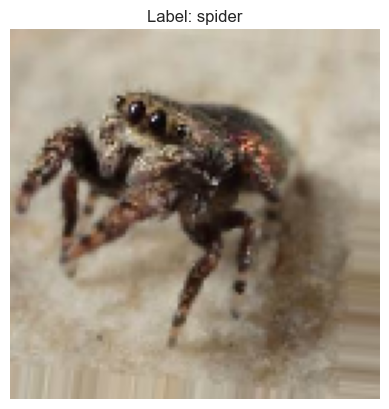

* Train - dog: 3404
* Train - horse: 1836
* Train - elephant: 1012
* Train - butterfly: 1478
* Train - chicken: 2168
* Train - cat: 1167
* Train - cow: 1306
* Train - sheep: 1274
* Train - spider: 3374
* Train - squirrel: 1303
* Validation - dog: 729
* Validation - horse: 393
* Validation - elephant: 216
* Validation - butterfly: 316
* Validation - chicken: 464
* Validation - cat: 250
* Validation - cow: 279
* Validation - sheep: 273
* Validation - spider: 723
* Validation - squirrel: 279
* Test - dog: 730
* Test - horse: 394
* Test - elephant: 218
* Test - butterfly: 318
* Test - chicken: 466
* Test - cat: 251
* Test - cow: 281
* Test - sheep: 273
* Test - spider: 724
* Test - squirrel: 280


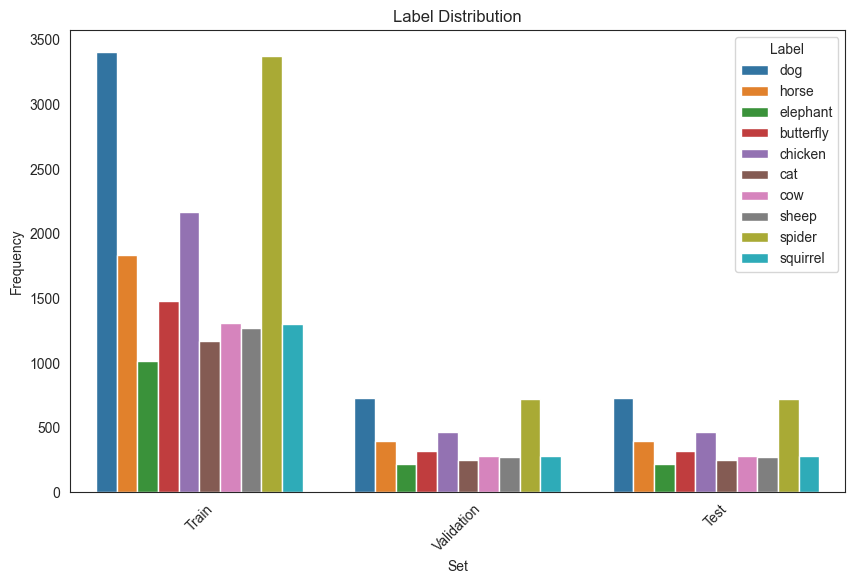

Model: "sequential_25"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_64 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_3 (Batc  (None, 126, 126, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_64 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_65 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_4 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                     

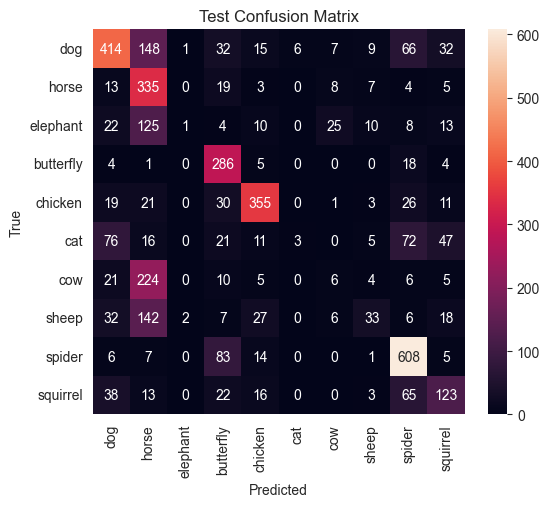

Test Set Report
              precision    recall  f1-score   support

         dog       0.64      0.57      0.60       730
       horse       0.32      0.85      0.47       394
    elephant       0.25      0.00      0.01       218
   butterfly       0.56      0.90      0.69       318
     chicken       0.77      0.76      0.77       466
         cat       0.33      0.01      0.02       251
         cow       0.11      0.02      0.04       281
       sheep       0.44      0.12      0.19       273
      spider       0.69      0.84      0.76       724
    squirrel       0.47      0.44      0.45       280

    accuracy                           0.55      3935
   macro avg       0.46      0.45      0.40      3935
weighted avg       0.52      0.55      0.49      3935


Validation Set Evaluation
123/123 [==============================] - 7s 55ms/step


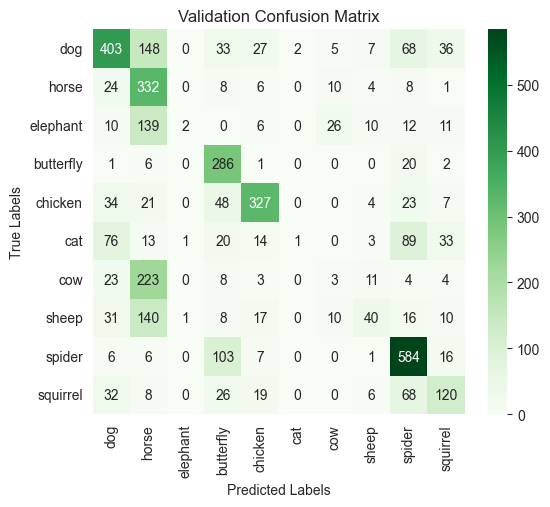

Validation Set Report
              precision    recall  f1-score   support

         dog       0.63      0.55      0.59       729
       horse       0.32      0.84      0.46       393
    elephant       0.50      0.01      0.02       216
   butterfly       0.53      0.91      0.67       316
     chicken       0.77      0.70      0.73       464
         cat       0.33      0.00      0.01       250
         cow       0.06      0.01      0.02       279
       sheep       0.47      0.15      0.22       273
      spider       0.65      0.81      0.72       723
    squirrel       0.50      0.43      0.46       279

    accuracy                           0.53      3922
   macro avg       0.48      0.44      0.39      3922
weighted avg       0.52      0.53      0.48      3922

Found 18322 images belonging to 10 classes.

Training Set Evaluation
573/573 [==============================] - 33s 57ms/step


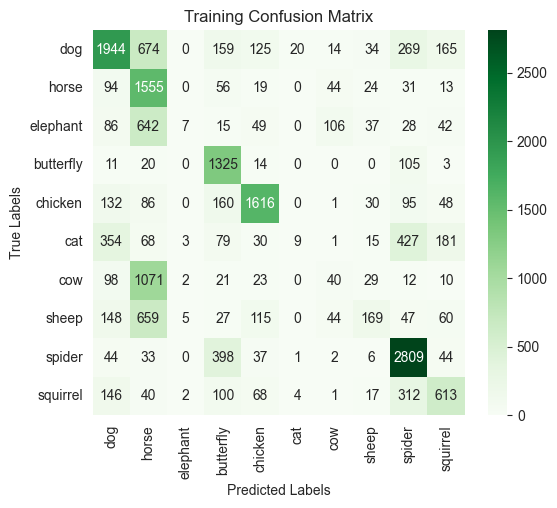

Training Set Report
              precision    recall  f1-score   support

         dog       0.64      0.57      0.60      3404
       horse       0.32      0.85      0.47      1836
    elephant       0.37      0.01      0.01      1012
   butterfly       0.57      0.90      0.69      1478
     chicken       0.77      0.75      0.76      2168
         cat       0.26      0.01      0.01      1167
         cow       0.16      0.03      0.05      1306
       sheep       0.47      0.13      0.21      1274
      spider       0.68      0.83      0.75      3374
    squirrel       0.52      0.47      0.49      1303

    accuracy                           0.55     18322
   macro avg       0.48      0.45      0.40     18322
weighted avg       0.53      0.55      0.50     18322



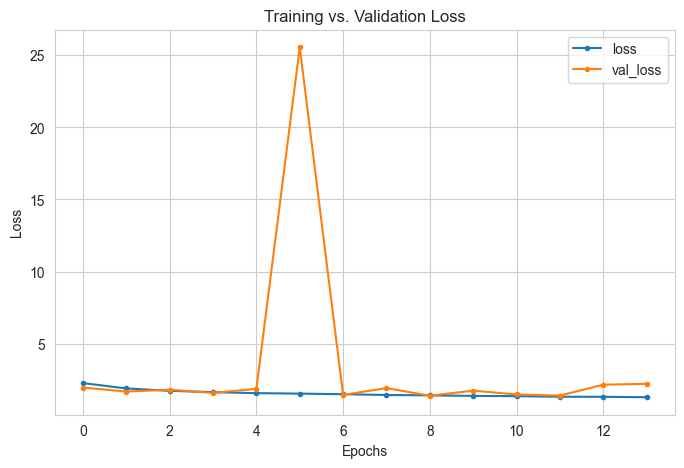

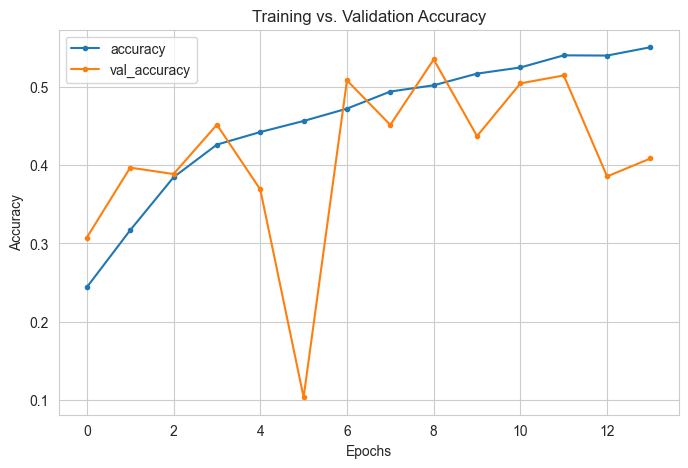

In [ ]:
import numpy as np          #Import the libraries needed for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loads and augments image data from folders 
from tensorflow.keras.models import Sequential # builds a neural netwrok layer by layer
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout # essential CNN building blocks 
from tensorflow.keras.callbacks import EarlyStopping # stops training when validation stops improving 
from sklearn.metrics import classification_report, confusion_matrix # model evaluation tools 

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # tf will show error messages only 
sns.set_style('white') # set plotting style 
img = (128, 128) # resizes all images to 128x128
batch = 32 # model processes 32 images at a time before updating its weights 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # checks if a GPU is available for training and prints the number of GPUs found


datapath = r"C:\Mechanical engineering\Big Data\BigData\raw-img" #stores the location of he raw data set 
print("using dataset path:", datapath) 
print("Contents:", os.listdir(datapath)) # shows folder names inside the dataset 
output_folder = r"C:\Mechanical engineering\Big Data\BigData\output_images"
splitfolders.ratio(datapath, output=output_folder, seed=42, ratio=(.7, .15, .15)) # splits teh data set into 70% training, 15% validation and 15% test data, the seed ensures the split is reproducible


train_dir = r"C:\Mechanical engineering\Big Data\BigData\output_images\train" # defines folder locations
val_dir   = r"C:\Mechanical engineering\Big Data\BigData\output_images\val"  
test_dir  = r"C:\Mechanical engineering\Big Data\BigData\output_images\test"

def check_images(generator, dataset_name): # image validation function
  
    invalid_count = 0  # Counter for invalid images
    valid_count = 0    # Counter for valid images

    
    num_batches = len(generator)
    print(f"Checking {dataset_name} ({generator.n} total images across {num_batches} batches)...")

    for batch_idx in range(num_batches):
        images, _ = generator[batch_idx]
        
        for img_idx, image in enumerate(images):
            if not isinstance(image, np.ndarray):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Not a valid image array")
                invalid_count += 1
                continue

            if image.shape != (128, 128, 3):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Incorrect shape {image.shape}")
                invalid_count += 1
                continue

            if not (image.min() >= 0.0 and image.max() <= 1.0):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Invalid scaled pixel values (Min: {image.min()}, Max: {image.max()})")
                invalid_count += 1
                continue

            if np.isnan(image).any():
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Contains NaN values")
                invalid_count += 1
                continue

            valid_count += 1

    print(f"=== {dataset_name} Check Complete ===")
    print(f"Valid images: {valid_count} | Invalid images: {invalid_count}\n")
    

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,      # Randomly rotate images up to 15 degrees
    width_shift_range=0.1,  # Randomly translate horizontally
    height_shift_range=0.1, # Randomly translate vertically
    shear_range=0.1,        # Apply shearing transformations
    zoom_range=0.1,         # Randomly zoom inside pictures
    horizontal_flip=True,   # Flip images horizontally
    fill_mode='nearest'
)

# converts pixel values from 0-255 to 0-1, this is important for training the model as it helps with convergence and stability during training.
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory( # loads the images from the folders and applies the rescaling transformation defined above
    train_dir,
    target_size=img,
    batch_size=batch,
    class_mode='categorical', # multi-class classification, labels are one-hot encoded
    shuffle=True # preserves randomness in the training data order, which can help with generalization during training.
)
val_data = val_test_datagen.flow_from_directory( 
    val_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False # preserves the original order of the validation data, which is important for accurate evaluation and comparison of predictions against true labels.
)
test_data = val_test_datagen.flow_from_directory( 
    test_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)

check_images(train_data, "Train Set") # runs the image validation function on the training, validation and test data to ensure all images are correctly loaded and preprocessed before training the model.
check_images(val_data, "Validation Set")
check_images(test_data, "Test Set")

italian_to_english = { # the original file names are in italian, so they just need to be translated to English  
    "cane": "dog",
    "gatto": "cat",
    "cavallo": "horse",
    "ragno": "spider",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "pecora": "sheep",
    "mucca": "cow",
    "scoiattolo": "squirrel",
    "elefante": "elephant"
}
original_classes = list(train_data.class_indices.keys()) # gets class names in TF's internal order
class_names = [italian_to_english[c] for c in original_classes] # converts eacg class name to english while keeping the correct order
print("Classes:", class_names) # displays final class list

images, labels = next(train_data) # loads one batch of an array of images and one-hot encoded labels, this is used to visualize a sample image and its corresponding label to verify that the data loading and preprocessing steps are working correctly.
plt.imshow(images[0]) # shows first image in the batch
plt.title(f"Label: {class_names[np.argmax(labels[0])]}") # finds index of class, class name and one-hot vector.
plt.axis('off') # removes axes for cleaner display
plt.show() # renders the image

df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency']) # creates an empty table using pandas to store how many of each differnte label there is and which set they are in. 

def labelcount(generator, dataset_name): # defines a function to count the labels 
    global df_freq # globals the variable 
    counts = generator.classes # gives an array of class indices fo r all images 
    unique, frequency  = np.unique(counts, return_counts=True) # using numpy the code finds all distinct values and how often they appear 
     #creates a new one row data frame with: data set name, label name and frequency
    for u, f in zip(unique, frequency): # loops through class index and frequency
        df_freq = pd.concat([     # the concat adds the new row to df_freq
            df_freq,
            pd.DataFrame([{
                'Set': dataset_name,
                'Label': class_names[u], # converts numeric label to readable name 
                'Frequency': f
            }])
        ], ignore_index=True) # resets row numbering 

        print(f"* {dataset_name} - {class_names[u]}: {f}") # prints the information out  

labelcount(train_data, "Train") # counts label distribution in training set
labelcount(val_data, "Validation") # counts label distribution in validation set
labelcount(test_data,"Test") # counts label distribution in test set

# Graph to display the distributrion of each label and their frequency 
plt.figure(figsize=(10, 6)) # creates the plot
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label') # creartes the bar graph using seaborn
plt.xticks(rotation=45) # rotates labels by 45 degrees for ease of reading 
plt.title("Label Distribution") # the title 
plt.show() # render the graph 

def build_tf_model(input_shape, n_labels): # creates the neural network 
    model = Sequential()

    # First Convolutional Block 
    model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=input_shape, activation='relu')) #learns 32 different filters to detect basic features like edges and textures, the kernel size of (3,3) means it looks at 3x3 pixel areas at a time, the activation function 'relu' helps the model learn complex patterns by introducing non-linearity.
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2))) # reduces the image dimension by taking the maximum value in each 2x2 region 

    # Second Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
     # Third Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    # Flattening the feature maps, converts the 2D feature maps into a 1D vector  and prepares data for the dense layers
    model.add(Flatten())

    model.add(Dense(128, activation='relu')) # standard neural network layer, 128 neurons and it learns the combinations of extracted features.
    model.add(Dropout(0.25))  # Randomly turns off 25% of neurons during training to prevent overfitting by forcing the model to learn more robust features that are not reliant on specific neurons.

    model.add(Dense(n_labels, activation='softmax')) # produces probabilities for each class, softmax converts outputs into probabilities 
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # compiles the model with categorical crossentropy loss (suitable for multi-class classification), the Adam optimizer (An efficiency focused optimizer)), and tracks accuracy as a performance metric.

    return model

# Variables based on configuration
INPUT_SHAPE = (128, 128, 3)  
N_LABELS = len(class_names)

model = build_tf_model(INPUT_SHAPE, N_LABELS) # model is built using the function defined above with the specified input shape and number of labels/classes.
model.summary()

# this code is designed to train the model, while stopping when it stops improving 
model.summary() # printsa  table showing each layer, the output shapes and the number of parameters.  
early_stop = EarlyStopping(   # creates an early stopping object from keras, a callback is something that runs during training to monitor or modify behaviour 
    monitor='val_loss', # tells the model to watch validation loss (how wrong the model is on validation data)
    patience=5, # waits 3 epochs before stopping if no movement, prevents stopping too early due to small fluctuations. 
    restore_best_weights=True # after stopping it goes back to the best model, not the last one trained
)
history = model.fit( # starts training the neural network
    train_data,  # data used to learn patterns 
    validation_data=val_data, # data used to evaluate performance during training 
    epochs=20, # maximum number of training cycles 
    callbacks=[early_stop] # tells keras to use the early stopping rule during training
)


print("\nTest Set Evaluation")
predictions = model.predict(test_data) # generates predictions for the test data, which are probabilities for each class.
y_pred_test = np.argmax(predictions, axis=1) #chooses highest probability class as the predicted label for each image in the test set.
cm_test = confusion_matrix(test_data.classes, y_pred_test) # shows the correct and incorrect predictions for each class
#displayes the results as a confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()
print("Test Set Report")
print(classification_report( 
    test_data.classes,  
    y_pred_test, 
    target_names=class_names 
))

# Repeats the same process as above on the validation set
print("\nValidation Set Evaluation")
predictions_val = model.predict(val_data) 
y_pred_val = np.argmax(predictions_val, axis=1)
cm_val = confusion_matrix(val_data.classes, y_pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Validation Confusion Matrix")
plt.show()
print("Validation Set Report")
print(classification_report( 
    val_data.classes,  
    y_pred_val, 
    target_names=class_names 
))

train_eval_data = val_test_datagen.flow_from_directory( # because train_data is shuffled, a new generator that loads the training data without shuffling must be made to ensure the predictions are aligned with the true labels for accurate evaluation.
    train_dir,        
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)


# Repeats the same process as above on the Training set
print("\nTraining Set Evaluation")
predictions_train = model.predict(train_eval_data)
y_pred_train = np.argmax(predictions_train, axis=1)
cm_train = confusion_matrix(train_eval_data.classes, y_pred_train)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Training Confusion Matrix")
plt.show()
print("Training Set Report")
print(classification_report( 
    train_eval_data.classes,  
    y_pred_train, 
    target_names=class_names 
))


history_df = pd.DataFrame(history.history) # stores the training history (loss and accuracy for each epoch) in a DataFrame for easier plotting and analysis.
sns.set_style("whitegrid")
history_df[['loss', 'val_loss']].plot(style='.-', figsize=(8, 5)) # plots the training and validation loss curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print("\n")
history_df[['accuracy', 'val_accuracy']].plot(style='.-', figsize=(8, 5)) # plots the training and validation accuracy curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Version 5
### 128,128 image size 
### 4th convolution layer has been added and the neuron density has been increased to 256 

Adding the extra convolution layer and increasing the neuron density has completely reversed the results of increasing the resolution to 128,128 and accuracy overall shows a massive improvement. The Training has increased to 85%, validation to 78% and the test to 79% these are by far the best results obtained so far and only having a 6% gap between the test and training data is also very good. 

Final changes to make to the model would be increasing the data augmentation and balancing the dataset 

Num GPUs Available:  2
using dataset path: C:\Mechanical engineering\Big Data\BigData\raw-img
Contents: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.
Checking Train Set (18322 total images across 573 batches)...
=== Train Set Check Complete ===
Valid images: 18322 | Invalid images: 0

Checking Validation Set (3922 total images across 123 batches)...
=== Validation Set Check Complete ===
Valid images: 3922 | Invalid images: 0

Checking Test Set (3935 total images across 123 batches)...
=== Test Set Check Complete ===
Valid images: 3935 | Invalid images: 0

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


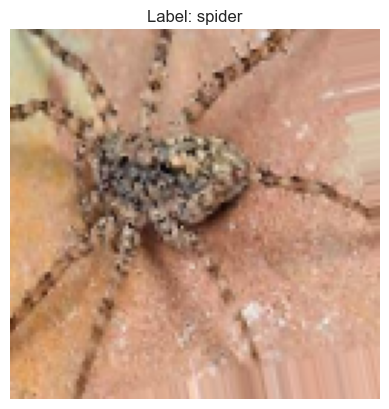

* Train - dog: 3404
* Train - horse: 1836
* Train - elephant: 1012
* Train - butterfly: 1478
* Train - chicken: 2168
* Train - cat: 1167
* Train - cow: 1306
* Train - sheep: 1274
* Train - spider: 3374
* Train - squirrel: 1303
* Validation - dog: 729
* Validation - horse: 393
* Validation - elephant: 216
* Validation - butterfly: 316
* Validation - chicken: 464
* Validation - cat: 250
* Validation - cow: 279
* Validation - sheep: 273
* Validation - spider: 723
* Validation - squirrel: 279
* Test - dog: 730
* Test - horse: 394
* Test - elephant: 218
* Test - butterfly: 318
* Test - chicken: 466
* Test - cat: 251
* Test - cow: 281
* Test - sheep: 273
* Test - spider: 724
* Test - squirrel: 280


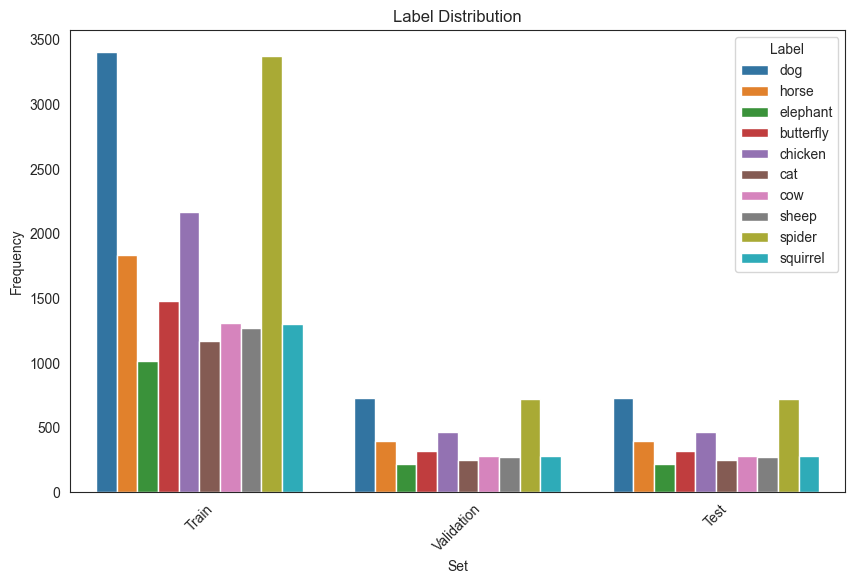

Model: "sequential_26"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_67 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 126, 126, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_67 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_68 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_7 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                     

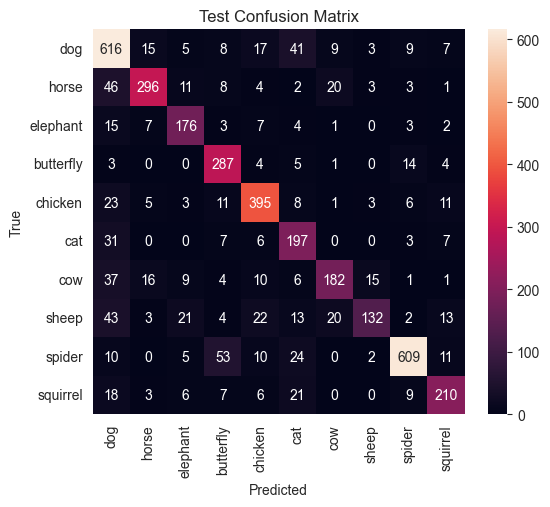

Test Set Report
              precision    recall  f1-score   support

         dog       0.73      0.84      0.78       730
       horse       0.86      0.75      0.80       394
    elephant       0.75      0.81      0.78       218
   butterfly       0.73      0.90      0.81       318
     chicken       0.82      0.85      0.83       466
         cat       0.61      0.78      0.69       251
         cow       0.78      0.65      0.71       281
       sheep       0.84      0.48      0.61       273
      spider       0.92      0.84      0.88       724
    squirrel       0.79      0.75      0.77       280

    accuracy                           0.79      3935
   macro avg       0.78      0.77      0.77      3935
weighted avg       0.80      0.79      0.79      3935


Validation Set Evaluation
123/123 [==============================] - 9s 69ms/step


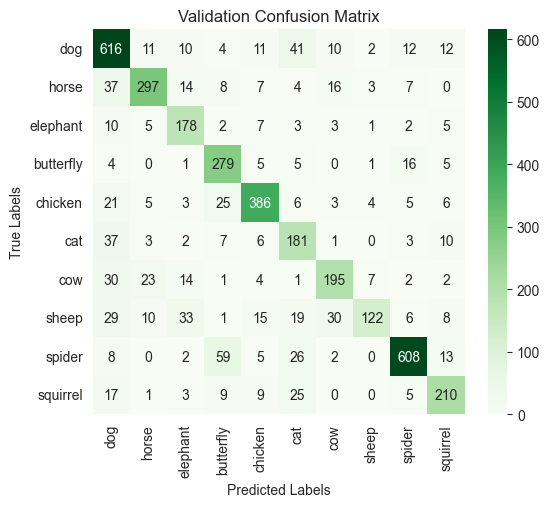

Validation Set Report
              precision    recall  f1-score   support

         dog       0.76      0.84      0.80       729
       horse       0.84      0.76      0.79       393
    elephant       0.68      0.82      0.75       216
   butterfly       0.71      0.88      0.78       316
     chicken       0.85      0.83      0.84       464
         cat       0.58      0.72      0.65       250
         cow       0.75      0.70      0.72       279
       sheep       0.87      0.45      0.59       273
      spider       0.91      0.84      0.88       723
    squirrel       0.77      0.75      0.76       279

    accuracy                           0.78      3922
   macro avg       0.77      0.76      0.76      3922
weighted avg       0.79      0.78      0.78      3922

Found 18322 images belonging to 10 classes.

Training Set Evaluation
573/573 [==============================] - 27s 47ms/step


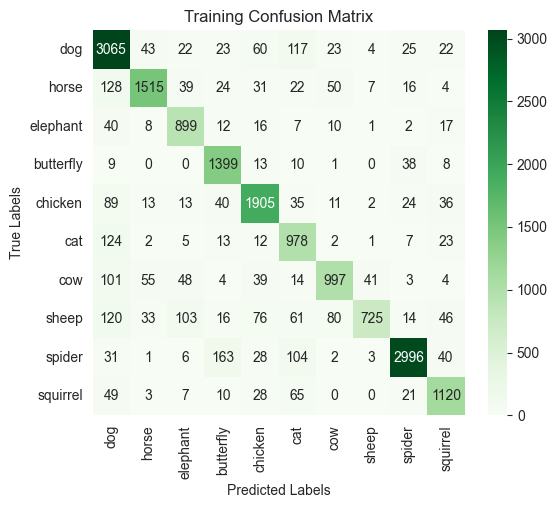

Training Set Report
              precision    recall  f1-score   support

         dog       0.82      0.90      0.86      3404
       horse       0.91      0.83      0.86      1836
    elephant       0.79      0.89      0.83      1012
   butterfly       0.82      0.95      0.88      1478
     chicken       0.86      0.88      0.87      2168
         cat       0.69      0.84      0.76      1167
         cow       0.85      0.76      0.80      1306
       sheep       0.92      0.57      0.70      1274
      spider       0.95      0.89      0.92      3374
    squirrel       0.85      0.86      0.85      1303

    accuracy                           0.85     18322
   macro avg       0.85      0.84      0.83     18322
weighted avg       0.86      0.85      0.85     18322



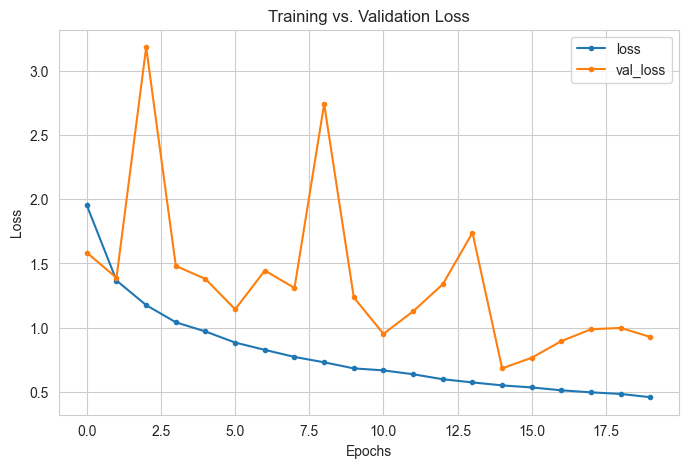

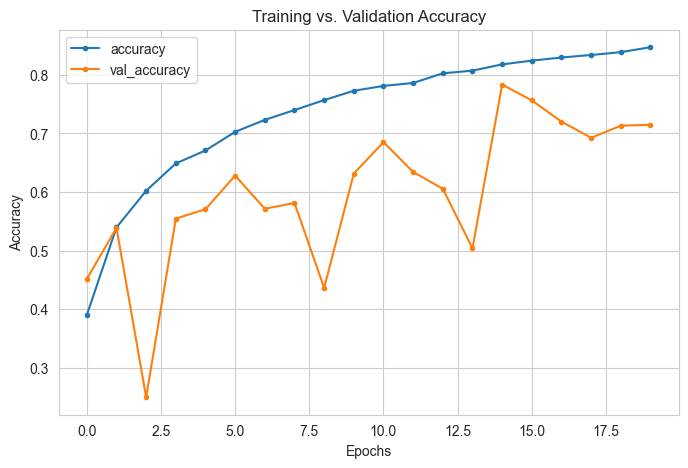

In [39]:
import numpy as np          #Import the libraries needed for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loads and augments image data from folders 
from tensorflow.keras.models import Sequential # builds a neural netwrok layer by layer
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout # essential CNN building blocks 
from tensorflow.keras.callbacks import EarlyStopping # stops training when validation stops improving 
from sklearn.metrics import classification_report, confusion_matrix # model evaluation tools 

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # tf will show error messages only 
sns.set_style('white') # set plotting style 
img = (128, 128) # resizes all images to 128x128
batch = 32 # model processes 32 images at a time before updating its weights 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # checks if a GPU is available for training and prints the number of GPUs found


datapath = r"C:\Mechanical engineering\Big Data\BigData\raw-img" #stores the location of he raw data set 
print("using dataset path:", datapath) 
print("Contents:", os.listdir(datapath)) # shows folder names inside the dataset 
output_folder = r"C:\Mechanical engineering\Big Data\BigData\output_images"
splitfolders.ratio(datapath, output=output_folder, seed=42, ratio=(.7, .15, .15)) # splits teh data set into 70% training, 15% validation and 15% test data, the seed ensures the split is reproducible


train_dir = r"C:\Mechanical engineering\Big Data\BigData\output_images\train" # defines folder locations
val_dir   = r"C:\Mechanical engineering\Big Data\BigData\output_images\val"  
test_dir  = r"C:\Mechanical engineering\Big Data\BigData\output_images\test"

def check_images(generator, dataset_name): # image validation function
  
    invalid_count = 0  # Counter for invalid images
    valid_count = 0    # Counter for valid images

    
    num_batches = len(generator)
    print(f"Checking {dataset_name} ({generator.n} total images across {num_batches} batches)...")

    for batch_idx in range(num_batches):
        images, _ = generator[batch_idx]
        
        for img_idx, image in enumerate(images):
            if not isinstance(image, np.ndarray):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Not a valid image array")
                invalid_count += 1
                continue

            if image.shape != (128, 128, 3):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Incorrect shape {image.shape}")
                invalid_count += 1
                continue

            if not (image.min() >= 0.0 and image.max() <= 1.0):
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Invalid scaled pixel values (Min: {image.min()}, Max: {image.max()})")
                invalid_count += 1
                continue

            if np.isnan(image).any():
                print(f"{dataset_name} - Batch {batch_idx}, Img {img_idx}: Contains NaN values")
                invalid_count += 1
                continue

            valid_count += 1

    print(f"=== {dataset_name} Check Complete ===")
    print(f"Valid images: {valid_count} | Invalid images: {invalid_count}\n")
    

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,      # Randomly rotate images up to 15 degrees
    width_shift_range=0.1,  # Randomly translate horizontally
    height_shift_range=0.1, # Randomly translate vertically
    shear_range=0.1,        # Apply shearing transformations
    zoom_range=0.1,         # Randomly zoom inside pictures
    horizontal_flip=True,   # Flip images horizontally
    fill_mode='nearest'
)

# converts pixel values from 0-255 to 0-1, this is important for training the model as it helps with convergence and stability during training.
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory( # loads the images from the folders and applies the rescaling transformation defined above
    train_dir,
    target_size=img,
    batch_size=batch,
    class_mode='categorical', # multi-class classification, labels are one-hot encoded
    shuffle=True # preserves randomness in the training data order, which can help with generalization during training.
)
val_data = val_test_datagen.flow_from_directory( 
    val_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False # preserves the original order of the validation data, which is important for accurate evaluation and comparison of predictions against true labels.
)
test_data = val_test_datagen.flow_from_directory( 
    test_dir,
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)

check_images(train_data, "Train Set") # runs the image validation function on the training, validation and test data to ensure all images are correctly loaded and preprocessed before training the model.
check_images(val_data, "Validation Set")
check_images(test_data, "Test Set")

italian_to_english = { # the original file names are in italian, so they just need to be translated to English  
    "cane": "dog",
    "gatto": "cat",
    "cavallo": "horse",
    "ragno": "spider",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "pecora": "sheep",
    "mucca": "cow",
    "scoiattolo": "squirrel",
    "elefante": "elephant"
}
original_classes = list(train_data.class_indices.keys()) # gets class names in TF's internal order
class_names = [italian_to_english[c] for c in original_classes] # converts eacg class name to english while keeping the correct order
print("Classes:", class_names) # displays final class list

images, labels = next(train_data) # loads one batch of an array of images and one-hot encoded labels, this is used to visualize a sample image and its corresponding label to verify that the data loading and preprocessing steps are working correctly.
plt.imshow(images[0]) # shows first image in the batch
plt.title(f"Label: {class_names[np.argmax(labels[0])]}") # finds index of class, class name and one-hot vector.
plt.axis('off') # removes axes for cleaner display
plt.show() # renders the image

df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency']) # creates an empty table using pandas to store how many of each differnte label there is and which set they are in. 

def labelcount(generator, dataset_name): # defines a function to count the labels 
    global df_freq # globals the variable 
    counts = generator.classes # gives an array of class indices fo r all images 
    unique, frequency  = np.unique(counts, return_counts=True) # using numpy the code finds all distinct values and how often they appear 
     #creates a new one row data frame with: data set name, label name and frequency
    for u, f in zip(unique, frequency): # loops through class index and frequency
        df_freq = pd.concat([     # the concat adds the new row to df_freq
            df_freq,
            pd.DataFrame([{
                'Set': dataset_name,
                'Label': class_names[u], # converts numeric label to readable name 
                'Frequency': f
            }])
        ], ignore_index=True) # resets row numbering 

        print(f"* {dataset_name} - {class_names[u]}: {f}") # prints the information out  

labelcount(train_data, "Train") # counts label distribution in training set
labelcount(val_data, "Validation") # counts label distribution in validation set
labelcount(test_data,"Test") # counts label distribution in test set

# Graph to display the distributrion of each label and their frequency 
plt.figure(figsize=(10, 6)) # creates the plot
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label') # creartes the bar graph using seaborn
plt.xticks(rotation=45) # rotates labels by 45 degrees for ease of reading 
plt.title("Label Distribution") # the title 
plt.show() # render the graph 

def build_tf_model(input_shape, n_labels): # creates the neural network 
    model = Sequential()

    # First Convolutional Block 
    model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=input_shape, activation='relu')) #learns 32 different filters to detect basic features like edges and textures, the kernel size of (3,3) means it looks at 3x3 pixel areas at a time, the activation function 'relu' helps the model learn complex patterns by introducing non-linearity.
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2))) # reduces the image dimension by taking the maximum value in each 2x2 region 

    # Second Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
     # Third Convolutional Block to extract more advanced features
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
    model.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu')) # learns 64 different filters
    model.add(tf.keras.layers.BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    # Flattening the feature maps, converts the 2D feature maps into a 1D vector  and prepares data for the dense layers
    model.add(Flatten())

    model.add(Dense(256, activation='relu')) # standard neural network layer, 128 neurons and it learns the combinations of extracted features.
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Dropout(0.5))  # Randomly turns off 50% of neurons during training to prevent overfitting by forcing the model to learn more robust features that are not reliant on specific neurons.

    model.add(Dense(n_labels, activation='softmax')) # produces probabilities for each class, softmax converts outputs into probabilities 
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # compiles the model with categorical crossentropy loss (suitable for multi-class classification), the Adam optimizer (An efficiency focused optimizer)), and tracks accuracy as a performance metric.

    return model

# Variables based on configuration
INPUT_SHAPE = (128, 128, 3)  
N_LABELS = len(class_names)

model = build_tf_model(INPUT_SHAPE, N_LABELS) # model is built using the function defined above with the specified input shape and number of labels/classes.
model.summary()

# this code is designed to train the model, while stopping when it stops improving 
model.summary() # printsa  table showing each layer, the output shapes and the number of parameters.  
early_stop = EarlyStopping(   # creates an early stopping object from keras, a callback is something that runs during training to monitor or modify behaviour 
    monitor='val_loss', # tells the model to watch validation loss (how wrong the model is on validation data)
    patience=5, # waits 3 epochs before stopping if no movement, prevents stopping too early due to small fluctuations. 
    restore_best_weights=True # after stopping it goes back to the best model, not the last one trained
)
history = model.fit( # starts training the neural network
    train_data,  # data used to learn patterns 
    validation_data=val_data, # data used to evaluate performance during training 
    epochs=20, # maximum number of training cycles 
    callbacks=[early_stop] # tells keras to use the early stopping rule during training
)


print("\nTest Set Evaluation")
predictions = model.predict(test_data) # generates predictions for the test data, which are probabilities for each class.
y_pred_test = np.argmax(predictions, axis=1) #chooses highest probability class as the predicted label for each image in the test set.
cm_test = confusion_matrix(test_data.classes, y_pred_test) # shows the correct and incorrect predictions for each class
#displayes the results as a confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()
print("Test Set Report")
print(classification_report( 
    test_data.classes,  
    y_pred_test, 
    target_names=class_names 
))

# Repeats the same process as above on the validation set
print("\nValidation Set Evaluation")
predictions_val = model.predict(val_data) 
y_pred_val = np.argmax(predictions_val, axis=1)
cm_val = confusion_matrix(val_data.classes, y_pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Validation Confusion Matrix")
plt.show()
print("Validation Set Report")
print(classification_report( 
    val_data.classes,  
    y_pred_val, 
    target_names=class_names 
))

train_eval_data = val_test_datagen.flow_from_directory( # because train_data is shuffled, a new generator that loads the training data without shuffling must be made to ensure the predictions are aligned with the true labels for accurate evaluation.
    train_dir,        
    target_size=img, 
    batch_size=batch,
    class_mode='categorical',
    shuffle=False 
)


# Repeats the same process as above on the Training set
print("\nTraining Set Evaluation")
predictions_train = model.predict(train_eval_data)
y_pred_train = np.argmax(predictions_train, axis=1)
cm_train = confusion_matrix(train_eval_data.classes, y_pred_train)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', 
            cmap='Greens', # Green theme to differentiate from the test matrix
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Training Confusion Matrix")
plt.show()
print("Training Set Report")
print(classification_report( 
    train_eval_data.classes,  
    y_pred_train, 
    target_names=class_names 
))


history_df = pd.DataFrame(history.history) # stores the training history (loss and accuracy for each epoch) in a DataFrame for easier plotting and analysis.
sns.set_style("whitegrid")
history_df[['loss', 'val_loss']].plot(style='.-', figsize=(8, 5)) # plots the training and validation loss curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print("\n")
history_df[['accuracy', 'val_accuracy']].plot(style='.-', figsize=(8, 5)) # plots the training and validation accuracy curves over epochs to visualize how the model's performance evolves during training.
plt.title("Training vs. Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()